# Santander Customer Transaction Prediction – kompakte EDA + XGBoost mit sauberer äußerer 5-Fold-CV

Ziel dieses Notebooks ist **nicht**, möglichst viele Standardplots zu erzeugen. Jeder Abschnitt beantwortet eine konkrete Frage und bereitet eine begründete Entscheidung für die Modellierung vor.

## Leitfragen
1. Liegt der erwartete Datensatz technisch korrekt vor?
2. Lohnt sich `float32` für den großen Datensatz?
3. Wie wird ein neuer finaler Holdout nach dem methodischen Reset prospektiv gesperrt?
4. Sind die Entwicklungsdaten technisch sauber?
5. Welche Variablentypen liegen vor und wie unterscheiden sich die numerischen Verteilungen?
6. Gibt es ein relevantes Klassenungleichgewicht?
7. Welche Features zeigen die stärksten univariaten Unterschiede?
8. Sind Features untereinander stark linear redundant?
9. Welche Konsequenzen ergeben sich daraus für kNN, K-Means und XGBoost?
10. Wie stabil ist eine XGBoost-Baseline über **5 äußere stratifizierte Folds**, wenn Early Stopping ausschließlich innerhalb des jeweiligen Trainingsfolds erfolgt?

> Die 200 Features sind anonymisiert. Auffälligkeiten werden deshalb **statistisch**, nicht fachlich interpretiert.

> **Methodischer Reset:** Ein früherer Test-/Validation-Split wurde bereits ausgewertet und wird nicht als finales Ergebnis verwendet. In dieser Version wird ein neuer Holdout erzeugt und ab diesem Zeitpunkt prospektiv gesperrt. Da derselbe Gesamtdatensatz zuvor bereits explorativ betrachtet wurde, kann rückwirkend keine vollständig externe Unabhängigkeit hergestellt werden. Die folgende Trennung ist die strengste praktikable Vorgehensweise innerhalb des verfügbaren Datensatzes.

> Für eine saubere Ausführung: **Kernel neu starten und dieses Notebook von oben ausführen.**


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 25)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

# Separater Seed für den nach dem methodischen Reset neu erzeugten Holdout.
FINAL_HOLDOUT_RANDOM_STATE = 20260808

FILE_PATH = Path.cwd() / "dataset"

versions = pd.DataFrame({
    "Software": ["Python", "pandas", "NumPy", "SciPy", "Matplotlib", "scikit-learn"],
    "Version": [
        sys.version.split()[0],
        pd.__version__,
        np.__version__,
        scipy.__version__,
        matplotlib.__version__,
        sklearn.__version__
    ]
})
display(versions)


,Software,Version
0,Python,3.13.5
1,pandas,3.0.5
2,NumPy,2.5.1
3,SciPy,1.18.0
4,Matplotlib,3.11.1
5,scikit-learn,1.9.0


## 1. Liegt der erwartete Datensatz vor?

**Frage:** Ist die Datei vorhanden, welches Format hat sie und besitzt sie die erwartete Santander-Struktur?


In [ ]:
if not FILE_PATH.is_file():
    raise FileNotFoundError(
        "Die Datei 'dataset' muss im gleichen Ordner wie das Notebook liegen."
    )

with open(FILE_PATH, "rb") as f:
    header = f.read(2000)

if b"@relation" in header.lower() or b"@attribute" in header.lower():
    from scipy.io import arff
    data, metadata = arff.loadarff(FILE_PATH)
    df = pd.DataFrame(data)

    for c in df.select_dtypes(include="object").columns:
        df[c] = df[c].map(
            lambda v: v.decode("utf-8") if isinstance(v, bytes) else v
        )
    detected_format = "ARFF"
else:
    raise ValueError("Die Datei wurde nicht als erwartete ARFF-Datei erkannt.")

TARGET = "target"
feature_columns = [c for c in df.columns if c.startswith("var_")]

# Harte Strukturkontrollen: falsche oder unerwartete Datei früh erkennen.
assert df.shape == (200_000, 201), f"Unerwartete Form: {df.shape}"
assert len(feature_columns) == 200, f"Unerwartete Feature-Anzahl: {len(feature_columns)}"
assert TARGET in df.columns, "Zielvariable 'target' fehlt."

X = df[feature_columns].copy()
y_original = df[TARGET].copy()

mapping = {"False": 0, "True": 1, False: 0, True: 1, 0: 0, 1: 1}
y = y_original.map(mapping)

if y.isna().any():
    unknown_targets = y_original[y.isna()].unique().tolist()
    raise ValueError(f"Unbekannte target-Werte gefunden: {unknown_targets}")

y = y.astype("int8")

display(pd.DataFrame({
    "Merkmal": ["Format", "Beobachtungen", "Features", "Zielvariable", "Dateigröße"],
    "Wert": [
        detected_format,
        len(df),
        len(feature_columns),
        TARGET,
        f"{FILE_PATH.stat().st_size / 1024**2:,.2f} MiB"
    ]
}))
display(df.head(3))


,Merkmal,Wert
0,Format,ARFF
1,Beobachtungen,200000
2,Features,200
3,Zielvariable,target
4,Dateigröße,298.39 MiB


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,...,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,0.5745,8.7989,...,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914,False
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,8.4135,5.4345,...,7.6543,-15.9319,13.3175,-0.3566,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518,False
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,-0.3249,-11.2648,14.1929,7.3124,7.5244,...,5.3745,-6.2660,10.1934,-0.8417,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965,False


## 2. Lohnt sich `float32`?

**Frage:** Kann der Speicherbedarf reduziert werden, ohne praktisch relevante numerische Information zu verlieren?

Die Umwandlung in `float32` ist eine deterministische technische Repräsentationsänderung und wird **vor** dem Split durchgeführt; sie lernt keine Parameter aus den Daten.


In [3]:
memory_before = X.memory_usage(deep=True).sum() / 1024**2
X32 = X.astype("float32")
memory_after = X32.memory_usage(deep=True).sum() / 1024**2

max_error = (
    X.astype("float64") - X32.astype("float64")
).abs().to_numpy().max()

display(pd.DataFrame({
    "Kennzahl": [
        "RAM Original [MiB]",
        "RAM float32 [MiB]",
        "Einsparung [%]"
    ],
    "Wert": [
        memory_before,
        memory_after,
        100 * (1 - memory_after / memory_before)
    ]
}))

print(f"Maximale absolute float32-Abweichung: {max_error:.10e}")
print("→ float32 wird für die folgenden rechenintensiven Schritte verwendet.")


,Kennzahl,Wert
0,RAM Original [MiB],305.1759
1,RAM float32 [MiB],152.5880
2,Einsparung [%],50.0000


Maximale absolute float32-Abweichung: 3.7963867214e-06
→ float32 wird für die folgenden rechenintensiven Schritte verwendet.


## 3. Prospektiv gesperrter finaler Holdout nach methodischem Reset

Der frühere Testlauf wurde bereits angesehen und wird deshalb verworfen. Hier wird ein **neuer stratifizierter 80/20-Split** erzeugt.

- **80 % Entwicklungsdaten (`X_dev`, `y_dev`)**: EDA, Cross-Validation, Modellwahl und Tuning.
- **20 % finaler Holdout (`X_final_holdout`, `y_final_holdout`)**: ab jetzt gesperrt und erst nach Abschluss aller Entscheidungen einmal verwenden.

**Methodische Einschränkung:** Da vor diesem Reset bereits mit demselben Gesamtdatensatz explorativ gearbeitet wurde, ist dieser Holdout nicht im strengen Sinn extern oder völlig „jungfräulich“. Ab dieser Notebook-Version wird er jedoch konsequent nicht mehr inspiziert und beeinflusst keine weitere Modellentscheidung.


In [73]:
from sklearn.model_selection import train_test_split

X_dev, X_final_holdout, y_dev, y_final_holdout = train_test_split(
    X32,
    y,
    test_size=0.20,
    stratify=y,
    random_state=FINAL_HOLDOUT_RANDOM_STATE
)

split_summary = pd.DataFrame({
    "Teil": ["Entwicklungsdaten", "Finaler Holdout"],
    "n": [len(X_dev), len(X_final_holdout)],
    "Verwendung": [
        "EDA + Cross-Validation + Tuning",
        "GESPERRT bis zur finalen Modellevaluation"
    ]
})
display(split_summary)

assert len(X_dev) == 160_000
assert len(X_final_holdout) == 40_000

print("→ Der finale Holdout wird ab hier nicht ausgewertet.")


,Teil,n,Verwendung
0,Entwicklungsdaten,160000,EDA + Cross-Validation + Tuning
1,Finaler Holdout,40000,GESPERRT bis zur finalen Modellevaluation


→ Der finale Holdout wird ab hier nicht ausgewertet.


Gesamtdaten: 200.000

├── 160.000 Entwicklungsdaten
│     ├── EDA
│     ├── Training
│     ├── Cross-Validation
│     ├── Modellvergleich
│     └── Hyperparameter-Tuning
│
└── 40.000 finaler Holdout
      🔒 NICHT ANSCHAUEN
      🔒 NICHT ZUM TUNING VERWENDEN
      🔒 NICHT ZUR MODELLWAHL VERWENDEN
      ↓
      erst ganz am Ende einmal testenx

## 4. Sind die Entwicklungsdaten technisch sauber?

**Frage:** Gibt es Missing Values, ±Inf, Duplikate oder konstante Features, die vor der Modellierung behandelt werden müssten?

Die Prüfung erfolgt bewusst nur auf den **Entwicklungsdaten**.


In [64]:
dev_df = X_dev.copy()
dev_df[TARGET] = y_dev.to_numpy()

# ------------------------------------------------------------
# 1. Grundlegende Datenqualitätsprüfungen
# ------------------------------------------------------------

# Fehlende Werte (NaN / None / pd.NA)
missing_total = int(dev_df.isna().sum().sum())

# Positive / negative Unendlich-Werte
inf_total = int(np.isinf(X_dev.to_numpy()).sum())

# Vollständig doppelte Zeilen inklusive Target
duplicate_rows = int(dev_df.duplicated().sum())

# Doppelte Spaltennamen
duplicate_column_names = X_dev.columns[X_dev.columns.duplicated()].tolist()

# Konstante Features: nur ein einziger eindeutiger Wert
nunique = X_dev.nunique(dropna=False)
constant_features = nunique[nunique <= 1].index.tolist()

# ------------------------------------------------------------
# 2. Zusätzliche Strukturprüfungen
# ------------------------------------------------------------

# Anzahl exakter Nullwerte pro Feature
zero_counts = (X_dev == 0).sum()
zero_total = int(zero_counts.sum())

# Feature mit dem höchsten Null-Anteil
zero_share = (X_dev == 0).mean()
max_zero_feature = zero_share.idxmax()
max_zero_share = float(zero_share.max())

# Features mit sehr geringer Varianz
feature_variance = X_dev.var()
low_variance_features = feature_variance[
    feature_variance < 1e-6
].index.tolist()

# ------------------------------------------------------------
# 3. Zusammenfassung
# ------------------------------------------------------------

quality_summary = pd.DataFrame({
    "Prüfung": [
        "Missing Values",
        "±Inf",
        "Doppelte Zeilen",
        "Doppelte Spaltennamen",
        "Konstante Features",
        "Exakte Nullwerte gesamt",
        "Features mit Varianz < 1e-6",
    ],
    "Anzahl": [
        missing_total,
        inf_total,
        duplicate_rows,
        len(duplicate_column_names),
        len(constant_features),
        zero_total,
        len(low_variance_features),
    ]
})

display(quality_summary)

print(
    f"Höchster Null-Anteil: {max_zero_feature} "
    f"mit {max_zero_share:.4%}"
)

# ------------------------------------------------------------
# 4. Entscheidung
# ------------------------------------------------------------

if (
    missing_total == 0
    and inf_total == 0
    and duplicate_rows == 0
    and len(duplicate_column_names) == 0
    and len(constant_features) == 0
):
    print(
        "→ Keine offensichtlichen strukturellen Datenqualitätsprobleme "
        "und keine zwingende Bereinigung/Imputation vor der Modellierung nötig."
    )

,Prüfung,Anzahl
0,Missing Values,0
1,±Inf,0
2,Doppelte Zeilen,0
3,Doppelte Spaltennamen,0
4,Konstante Features,0
5,Exakte Nullwerte gesamt,115
6,Features mit Varianz < 1e-6,0


Höchster Null-Anteil: var_131 mit 0.0081%
→ Keine offensichtlichen strukturellen Datenqualitätsprobleme und keine zwingende Bereinigung/Imputation vor der Modellierung nötig.


### Nullwerte

- Insgesamt **115 exakte Nullwerte** im Entwicklungsdatensatz.
- Gesamtzahl der Feature-Werte: **160.000 × 200 = 32 Mio.**
- Nullwerte sind damit **extrem selten**.
- `var_131` hat den höchsten Null-Anteil mit **0,0081 %**.
- Das entspricht bei 160.000 Zeilen ungefähr **13 Nullwerten** in `var_131`.
- Da die Features anonymisiert sind, werden `0`-Werte **nicht automatisch als fehlende Werte interpretiert**.

In [ ]:
expected_features = {f"var_{i}" for i in range(200)}
actual_features = set(X_dev.columns)

missing_feature_names = expected_features - actual_features
unexpected_feature_names = actual_features - expected_features
print(missing_feature_names)
print(unexpected_feature_names)

set()
set()


## 5. Welche Variablentypen und numerischen Verteilungen liegen vor?

Die Aufgabenstellung verlangt, Unterschiede zwischen Eigenschaften des Datensatzes zu berücksichtigen. Hier liegen zwei klar getrennte Rollen vor:

| Variablengruppe | Anzahl | Datentyp | Rolle |
|---|---:|---|---|
| `var_0`–`var_199` | 200 | kontinuierlich numerisch | Eingangsfeatures |
| `target` | 1 | binär/kategorial | Zielvariable |

Da die Features anonymisiert sind, können Maßeinheiten und fachliche Bedeutungen nicht interpretiert werden. Für die Modellwahl sind jedoch Unterschiede in **Streuung, IQR und Schiefe** relevant.


In [71]:
# ============================================================
# Verteilungsanalyse der Features
# Ziel:
# - Lage, Streuung und Form der 200 Feature-Verteilungen beschreiben
# - Unterschiede zwischen den Feature-Skalen erkennen
# - Hinweise auf Schiefe und mögliche Transformationen gewinnen
# ============================================================

feature_distribution = pd.DataFrame({
    "Minimum": X_dev.min(),
    "Q1": X_dev.quantile(0.25),
    "Median": X_dev.median(),
    "Mittelwert": X_dev.mean(),
    "Q3": X_dev.quantile(0.75),
    "Maximum": X_dev.max(),
    "Standardabweichung": X_dev.std(),
    "IQR": X_dev.quantile(0.75) - X_dev.quantile(0.25),
    "Schiefe": X_dev.skew(),
    "Kurtosis": X_dev.kurt()
})

# Kompakte Zusammenfassung über alle 200 Features
distribution_overview = pd.DataFrame({
    "Minimum über Features": feature_distribution.min(),
    "Median über Features": feature_distribution.median(),
    "Maximum über Features": feature_distribution.max()
})

display(distribution_overview)


# ------------------------------------------------------------
# Features mit stärkster Schiefe
# ------------------------------------------------------------

top_skew = (
    feature_distribution
    .assign(abs_Schiefe=feature_distribution["Schiefe"].abs())
    .nlargest(10, "abs_Schiefe")
    [["Schiefe", "Kurtosis", "Standardabweichung", "IQR", "Minimum", "Maximum"]]
)

display(top_skew)


print(
    "→ Die Verteilungsanalyse zeigt Lage, Streuung und Form der Features. "
    "Sie dient insbesondere zur Beurteilung der Feature-Skalen sowie zur "
    "begründeten Wahl der Vorverarbeitung für distanzbasierte Verfahren "
    "wie kNN und K-Means."
)

,Minimum über Features,Median über Features,Maximum über Features
Minimum,-90.2525,-5.4731,13.7290
Q1,-28.7380,5.1242,16.0357
Median,-16.4513,6.5932,24.4114
Mittelwert,-16.5387,6.5846,24.5351
Q3,-6.3991,8.7484,33.6233
Maximum,1.5719,18.4128,74.0321
Standardabweichung,0.0072,3.9387,21.4089
IQR,0.0100,5.8400,31.8912
Schiefe,-0.3387,0.0200,0.2639
Kurtosis,-0.8128,-0.5016,-0.0148


,Schiefe,Kurtosis,Standardabweichung,IQR,Minimum,Maximum
var_44,-0.3387,-0.1039,5.9007,7.7868,-9.9396,29.6690
var_168,0.2639,-0.1997,3.1038,4.3099,-5.2218,14.4076
var_2,0.2581,-0.3414,2.6420,3.7965,2.1171,18.6521
var_179,0.2417,-0.0148,2.8013,3.7690,-7.8561,13.4487
var_93,-0.2379,-0.1499,0.5435,0.7492,8.5204,12.5343
var_163,0.2365,-0.3443,5.2585,7.5921,-6.5317,27.5648
var_0,0.2341,-0.2772,3.0391,4.3049,0.4084,20.3150
var_81,-0.2321,-0.1980,2.2987,3.1243,7.5865,22.9300
var_80,-0.2215,-0.3982,7.4402,10.7554,-18.0422,30.4769
var_86,-0.2156,-0.2420,7.7501,10.7428,-19.2722,34.5637


→ Die Verteilungsanalyse zeigt Lage, Streuung und Form der Features. Sie dient insbesondere zur Beurteilung der Feature-Skalen sowie zur begründeten Wahl der Vorverarbeitung für distanzbasierte Verfahren wie kNN und K-Means.


### Verteilungsübersicht der Features

- Die Features unterscheiden sich stark in ihrer Streuung.
- Die Standardabweichungen reichen von **0.0072** bis **21.4089**, der IQR von **0.0100** bis **31.8912**.
- Damit liegen die Features auf sehr unterschiedlichen Skalen.
- Die Schiefe ist insgesamt gering (ca. **-0.34 bis 0.26**), sodass die meisten Features relativ symmetrisch verteilt wirken.
- Mittelwert und Median liegen häufig nah beieinander, was diese Einschätzung stützt.
- Für distanzbasierte Verfahren wie **kNN** und **K-Means** ist daher insbesondere **Skalierung** wichtig.
- Die Übersicht spricht eher für den Einsatz eines **StandardScalers** als für robustere Skalierungsvarianten.

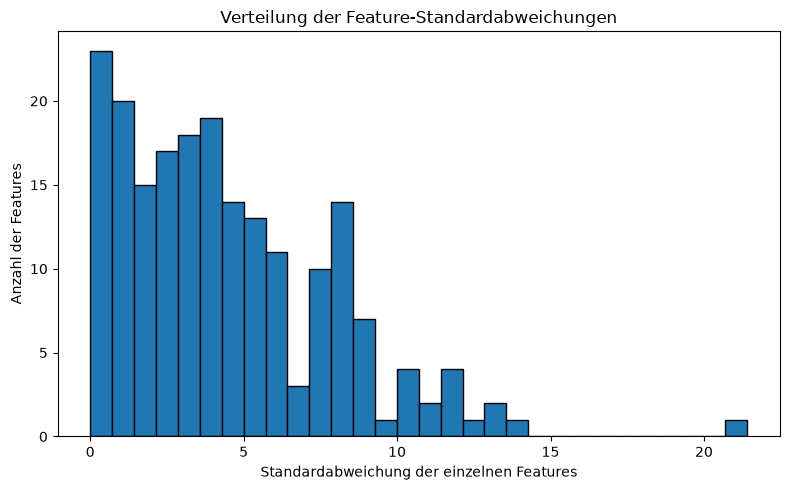

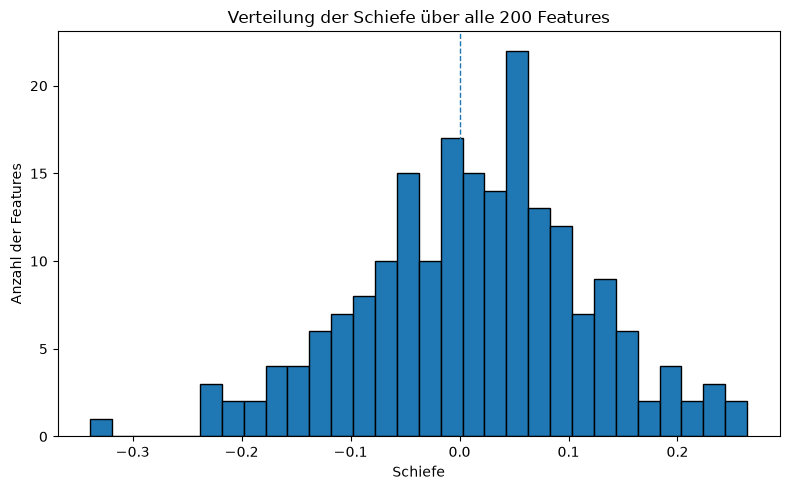

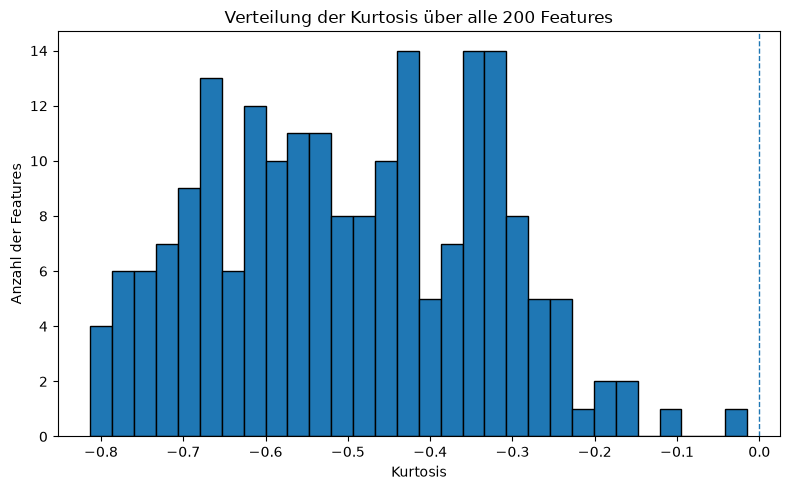

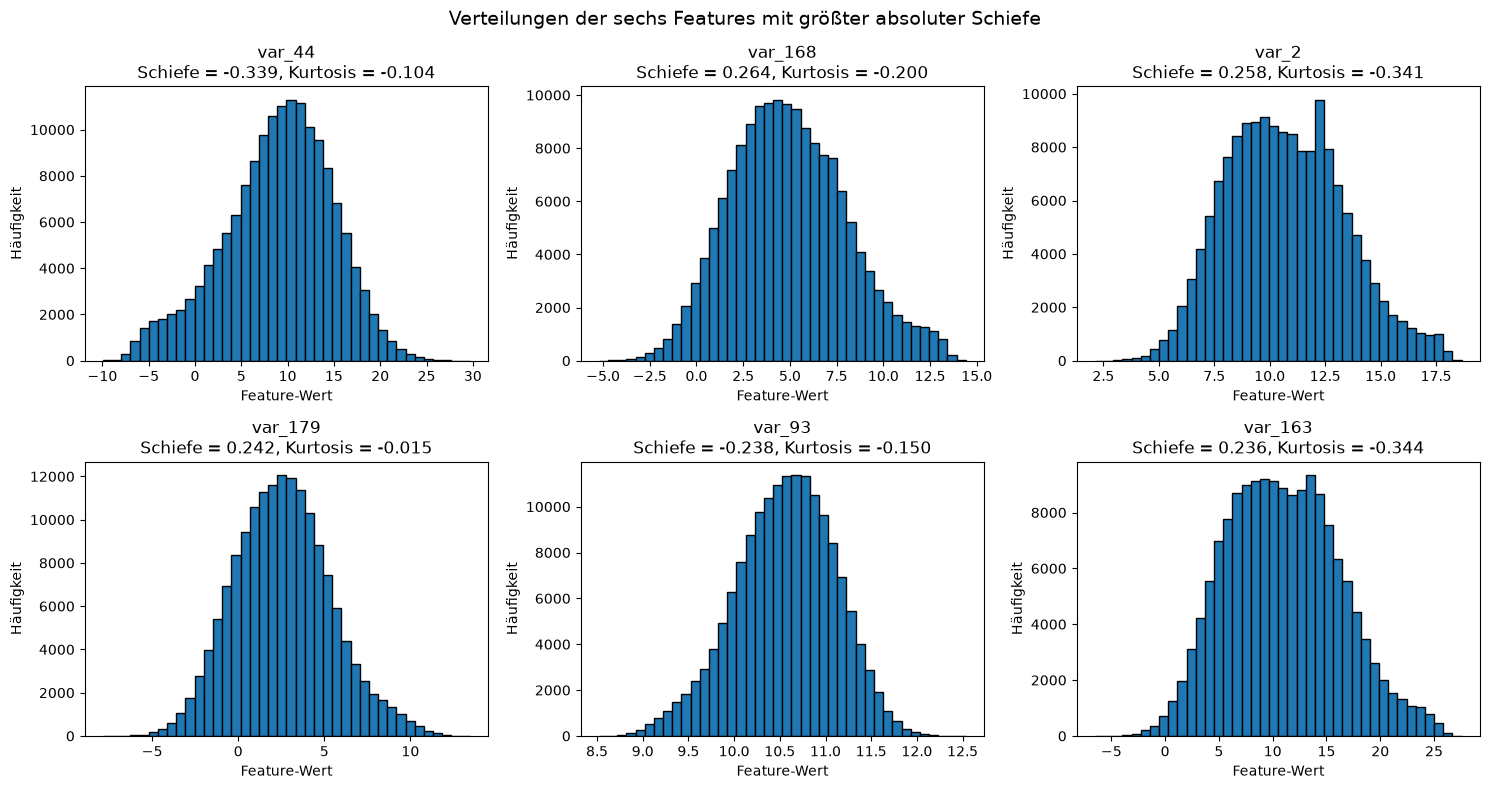

Interpretation:
→ Die Standardabweichungen unterscheiden sich zwischen den Features deutlich.
→ Für distanzbasierte Verfahren wie kNN und K-Means ist deshalb eine Skalierung wichtig.
→ Die Schiefe zeigt, ob Features deutlich asymmetrisch verteilt sind.
→ Die Kurtosis ergänzt die Analyse um Hinweise auf besonders spitze oder heavy-tailed Verteilungen.
→ Auffällige Features werden zusätzlich einzeln visualisiert, statt nur anhand aggregierter Kennzahlen beurteilt.


In [ ]:
# ============================================================
# Visualisierung der Feature-Verteilungen
# Ziel:
# 1. Unterschiede in der Streuung/Skalierung sichtbar machen
# 2. Schiefe der 200 Features beurteilen
# 3. Kurtosis als Hinweis auf besonders spitze / heavy-tailed
#    Verteilungen betrachten
# 4. Auffälligste Features exemplarisch visualisieren
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Verteilung der Standardabweichungen über alle Features
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    feature_distribution["Standardabweichung"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Standardabweichung der einzelnen Features")
plt.ylabel("Anzahl der Features")
plt.title("Verteilung der Feature-Standardabweichungen")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Verteilung der Schiefe über alle Features
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    feature_distribution["Schiefe"],
    bins=30,
    edgecolor="black"
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Schiefe")
plt.ylabel("Anzahl der Features")
plt.title("Verteilung der Schiefe über alle 200 Features")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Verteilung der Kurtosis über alle Features
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    feature_distribution["Kurtosis"],
    bins=30,
    edgecolor="black"
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Kurtosis")
plt.ylabel("Anzahl der Features")
plt.title("Verteilung der Kurtosis über alle 200 Features")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Features mit größter absoluter Schiefe
# ------------------------------------------------------------

top_skew_features = (
    feature_distribution["Schiefe"]
    .abs()
    .nlargest(6)
    .index
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.ravel(), top_skew_features):

    ax.hist(
        X_dev[feature],
        bins=40,
        edgecolor="black"
    )

    skew_value = feature_distribution.loc[feature, "Schiefe"]
    kurt_value = feature_distribution.loc[feature, "Kurtosis"]

    ax.set_title(
        f"{feature}\n"
        f"Schiefe = {skew_value:.3f}, "
        f"Kurtosis = {kurt_value:.3f}"
    )

    ax.set_xlabel("Feature-Wert")
    ax.set_ylabel("Häufigkeit")


plt.suptitle(
    "Verteilungen der sechs Features mit größter absoluter Schiefe",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Interpretation
# ------------------------------------------------------------

print("Die 6 wurden nicht zufällig ausgewählt. Das sind die Features mit der größten absoluten Schiefe, egal ob es Links oder Rechts")

### Interpretation der Feature-Verteilungen

Die 200 numerischen Features unterscheiden sich deutlich in ihrer Streuung. 
Die Standardabweichungen reichen von sehr kleinen Werten bis zu etwa 21, sodass die Features auf unterschiedlichen Skalen liegen. Für distanzbasierte Verfahren wie **kNN und K-Means** ist daher eine Standardisierung erforderlich, damit Features mit hoher Streuung die Distanzberechnung nicht dominieren.

Die **Schiefe** liegt insgesamt nahe bei 0 (ca. −0,34 bis +0,26). Die meisten Features sind damit nur schwach links- oder rechtsschief und zeigen überwiegend annähernd symmetrische Verteilungen. Auch die Features mit der größten absoluten Schiefe weisen keine stark verzerrten Verteilungen auf.

Die **Kurtosis** ist bei allen Features überwiegend negativ (ca. −0,8 bis 0). Da `pandas.kurt()` die Excess-Kurtosis verwendet, entspricht 0 der Kurtosis einer Normalverteilung. Die negativen Werte deuten daher auf tendenziell etwas flachere Verteilungen hin, ohne dass extreme Abweichungen erkennbar sind.

**Konsequenzen für die Modellierung:**
- **Skalierung:** notwendig für kNN und K-Means aufgrund der unterschiedlichen Feature-Streuungen.
- **Transformation:** aus Schiefe und Kurtosis ergibt sich zunächst kein deutlicher Bedarf für zusätzliche Log- oder Power-Transformationen.
- Die Verteilungen wirken insgesamt relativ regelmäßig; Ausreißer werden separat untersucht.
---
+ Schiefe sagt: zieht die Verteilung eher nach links oder rechts?
+ Kurtosis sagt: ist sie eher spitz/heavy-tailed oder eher flach?

## 6. Unterscheiden sich die Feature-Skalen stark?

**Frage:** Können einzelne Features bei Distanzverfahren allein aufgrund ihrer Streuung dominieren?

Diese Frage ist für **kNN und K-Means** relevant. XGBoost benötigt dagegen keine Skalierung aus Distanzgründen.


In [ ]:
std = X_dev.std()
std_ratio = float(std.max() / std.min())

display(pd.DataFrame({
    "Kennzahl": ["größte / kleinste Feature-Standardabweichung"],
    "Wert": [std_ratio]
}))

print(
    "→ Die Streuungen unterscheiden sich stark. "
    "Für kNN/K-Means wird Scaling als notwendige Vorverarbeitungsvariante untersucht, "
    "weil sonst Features mit größerer Skala Distanzmaße dominieren können."
)


,Kennzahl,Wert
0,größte / kleinste Feature-Standardabweichung,"2,981.6843"


→ Die Streuungen unterscheiden sich stark. Für kNN/K-Means wird Scaling als notwendige Vorverarbeitungsvariante untersucht, weil sonst Features mit größerer Skala Distanzmaße dominieren können.


## 7. Ist die Zielvariable unausgeglichen?

**Frage:** Wie groß ist die positive Klasse **innerhalb der Entwicklungsdaten**?

Das beeinflusst die Wahl von Split-Verfahren und Evaluationsmetriken.


In [ ]:
top_features_eda = association.nlargest(10, "|Cohen's d|").sort_values("Cohen's d")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

target_table["Anzahl"].plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Entwicklungsdaten: Klassenverteilung")
axes[0].set_xlabel("target")
axes[0].set_ylabel("Anzahl")
axes[0].tick_params(axis="x", rotation=0)

top_features_eda["Cohen's d"].plot(kind="barh", ax=axes[1], edgecolor="black")
axes[1].set_title("Top-10 univariate Effekte")
axes[1].set_xlabel("Cohen's d (positiv minus negativ)")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()


,Anzahl,Anteil [%]
False,143922,89.9513
True,16078,10.0488


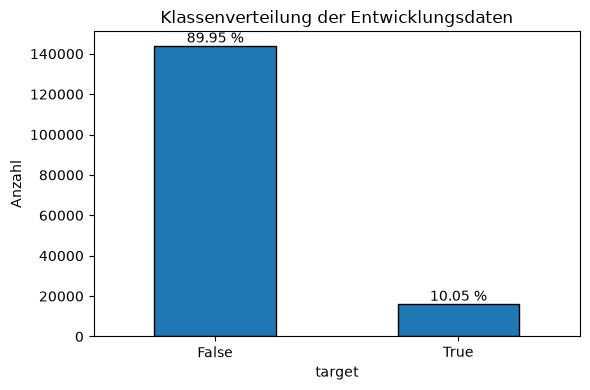

Positive Klasse in den Entwicklungsdaten: 10.05%
PR-AUC-Basisrate einer uninformierten Rangfolge: ungefähr 0.1005
→ Stratified CV; ROC-AUC und besonders PR-AUC sind aussagekräftiger als Accuracy allein.


In [ ]:
target_table = pd.DataFrame({
    "Anzahl": y_dev.value_counts().sort_index(),
    "Anteil [%]": y_dev.value_counts(normalize=True).sort_index() * 100
})
target_table.index = ["False", "True"]
display(target_table)

ax = target_table["Anzahl"].plot(kind="bar", figsize=(6, 4), edgecolor="black")
ax.set_title("Klassenverteilung der Entwicklungsdaten")
ax.set_xlabel("target")
ax.set_ylabel("Anzahl")
ax.tick_params(axis="x", rotation=0)

for i, (count, share) in enumerate(zip(target_table["Anzahl"], target_table["Anteil [%]"])):
    ax.text(i, count, f"{share:.2f} %", ha="center", va="bottom")

plt.tight_layout()
plt.show()

positive_share = float(y_dev.mean())
print(f"Positive Klasse in den Entwicklungsdaten: {positive_share:.2%}")
print(f"PR-AUC-Basisrate einer uninformierten Rangfolge: ungefähr {positive_share:.4f}")
print("→ Stratified CV; ROC-AUC und besonders PR-AUC sind aussagekräftiger als Accuracy allein.")


### Klassenverteilung des Targets

Die Entwicklungsdaten sind deutlich unausgeglichen:

- `False`: **89,95 %**
- `True`: **10,05 %**

Damit liegt ein Verhältnis von ungefähr **9:1** zugunsten der negativen Klasse vor.

**Konsequenz für die Modellierung:**
- Accuracy allein ist nicht ausreichend, da bereits eine triviale Vorhersage von ausschließlich `False` fast 90 % Accuracy erreichen würde.
- Es wird daher **stratifizierte Cross-Validation** verwendet.
- Neben ROC-AUC ist insbesondere **PR-AUC** relevant.
- Die PR-AUC-Basisrate beträgt aufgrund des Anteils der positiven Klasse ungefähr **0,1005**.
___

### Wahl der Bewertungsmetriken

Da die Zielvariable deutlich unausgeglichen ist (`False`: **89,95 %**, `True`: **10,05 %**), ist **Accuracy allein nicht ausreichend**.

- **ROC-AUC** misst, wie gut das Modell positive und negative Fälle insgesamt voneinander trennen bzw. korrekt ranken kann.
  - **0,5** ≈ Zufall
  - **1,0** = perfekte Trennung

- **PR-AUC** bewertet speziell die seltene positive Klasse und basiert auf **Precision** und **Recall**.
  - Sie ist bei unausgeglichenen Klassen besonders aussagekräftig.
  - Die PR-AUC-Basisrate entspricht ungefähr dem Anteil der positiven Klasse und liegt hier bei **0,1005**.

**Für diesen Datensatz ist PR-AUC daher besonders wichtig**, während ROC-AUC zusätzlich die allgemeine Trennleistung des Modells beschreibt.

## 8. Welche Features unterscheiden die Zielklassen am stärksten?

**Frage:** Gibt es einzelne Features mit klarer linearer bzw. standardisierter Trenninformation?

Wir verwenden zwei komplementäre Maße:
- **Pearson-Korrelation** mit dem binären Target
- **Cohen's d** als standardisierte Mittelwertdifferenz

Alle Berechnungen verwenden ausschließlich die Entwicklungsdaten.

> **Leakage-Regel:** Diese target-basierten Rankings dienen hier nur der **Exploration**. Falls sie später für eine echte Feature-Auswahl verwendet werden, muss die Auswahl innerhalb jedes jeweiligen Trainingsfolds neu berechnet werden. Die äußeren Validierungsdaten dürfen die Feature-Selektion nicht beeinflussen.


,Pearson,Cohens_d
var_81,-0.0800,-0.2671
var_139,-0.0731,-0.2438
var_12,-0.0701,-0.2338
var_6,0.0693,0.2309
var_146,-0.0655,-0.2184
var_110,0.0647,0.2155
var_53,0.0636,0.2118
var_26,0.0627,0.2088
var_22,0.0617,0.2058
var_76,-0.0615,-0.2049


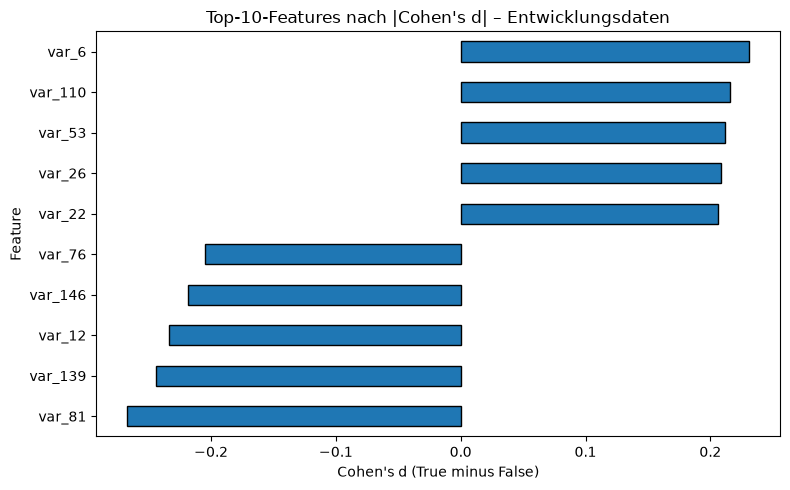

Max |Pearson|: 0.0800
Max |Cohen's d|: 0.2671
→ Die geringe univariate Trennwirkung legt die Hypothese nahe, dass relevante Vorhersageinformation aus der Kombination mehrerer Features entsteht. Diese Hypothese wird mit multivariaten Modellen geprüft.


In [ ]:
pearson_target = X_dev.corrwith(y_dev)

mask0 = y_dev.eq(0)
mask1 = y_dev.eq(1)

cohens_d = {}
for col in X_dev.columns:
    a = X_dev.loc[mask0, col]
    b = X_dev.loc[mask1, col]
    n0, n1 = len(a), len(b)
    s0, s1 = a.std(ddof=1), b.std(ddof=1)

    pooled_sd = np.sqrt(
        (((n0 - 1) * s0**2) + ((n1 - 1) * s1**2)) / (n0 + n1 - 2)
    )

    cohens_d[col] = (
        (b.mean() - a.mean()) / pooled_sd
        if pooled_sd > 0 else np.nan
    )

assoc = pd.DataFrame({
    "Pearson": pearson_target,
    "Cohens_d": pd.Series(cohens_d)
})
assoc["abs_Pearson"] = assoc["Pearson"].abs()
assoc["abs_Cohens_d"] = assoc["Cohens_d"].abs()

top_effect = assoc.nlargest(10, "abs_Cohens_d")
display(top_effect[["Pearson", "Cohens_d"]])

ax = top_effect.sort_values("Cohens_d")["Cohens_d"].plot(
    kind="barh", figsize=(8, 5), edgecolor="black"
)
ax.set_title("Top-10-Features nach |Cohen's d| – Entwicklungsdaten")
ax.set_xlabel("Cohen's d (True minus False)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print(f"Max |Pearson|: {assoc['abs_Pearson'].max():.4f}")
print(f"Max |Cohen's d|: {assoc['abs_Cohens_d'].max():.4f}")
print(
    "→ Die geringe univariate Trennwirkung legt die Hypothese nahe, "
    "dass relevante Vorhersageinformation aus der Kombination mehrerer Features entsteht. "
    "Diese Hypothese wird mit multivariaten Modellen geprüft."
)


### Zusammenhang einzelner Features mit der Zielvariable

Die stärksten einzelnen Features zeigen nur geringe bis moderate Unterschiede zwischen den beiden Target-Klassen.

- `var_81` weist mit **Cohen's d ≈ −0,267** den stärksten Effekt auf.
- Positive Effektgrößen (z. B. `var_6`) bedeuten, dass die Feature-Werte bei `target=True` im Mittel höher liegen.
- Negative Effektgrößen (z. B. `var_81`) bedeuten, dass die Werte bei `target=True` im Mittel niedriger liegen.
- Auch die Pearson-Korrelationen mit dem Target sind insgesamt gering; der größte Betrag liegt nur bei ungefähr **0,08**.

**Zentrale Erkenntnis:**  
Kein einzelnes Feature besitzt eine starke Trennwirkung. Die relevante Vorhersageinformation liegt daher vermutlich in der **gemeinsamen Kombination mehrerer Features**, was den Einsatz multivariater Modelle wie XGBoost begründet.

## 9. Sind die Unterschiede der stärksten Features auch visuell sichtbar?

**Frage:** Wie sehen die Verteilungen der vier stärksten Features in beiden Zielklassen aus?


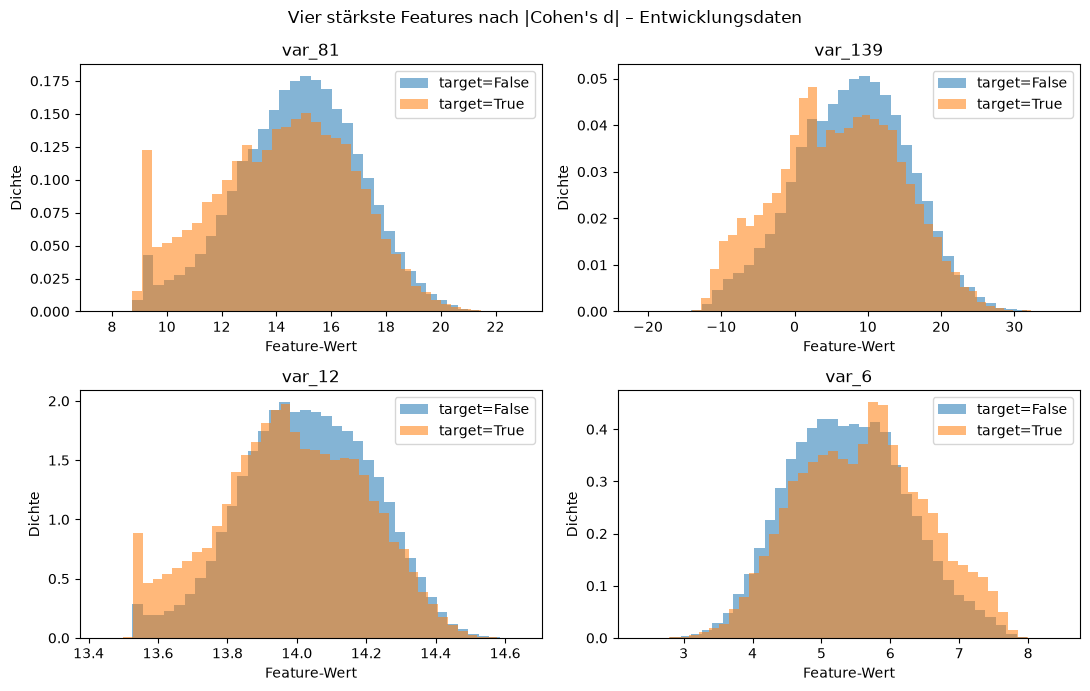

In [ ]:
comparison_features = assoc.nlargest(4, "abs_Cohens_d").index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

for ax, col in zip(axes, comparison_features):
    ax.hist(
        X_dev.loc[mask0, col],
        bins=40,
        density=True,
        alpha=0.55,
        label="target=False"
    )
    ax.hist(
        X_dev.loc[mask1, col],
        bins=40,
        density=True,
        alpha=0.55,
        label="target=True"
    )
    ax.set_title(col)
    ax.set_xlabel("Feature-Wert")
    ax.set_ylabel("Dichte")
    ax.legend()

fig.suptitle("Vier stärkste Features nach |Cohen's d| – Entwicklungsdaten")
plt.tight_layout()
plt.show()


## 10. Sind Features untereinander redundant?

**Frage:** Gibt es starke lineare Feature-Feature-Korrelationen?

Die Korrelation wird auf **allen 160.000 Entwicklungsbeobachtungen** berechnet. Eine Stichprobe ist bei 200 Features nicht notwendig und müsste sonst zusätzlich begründet werden.


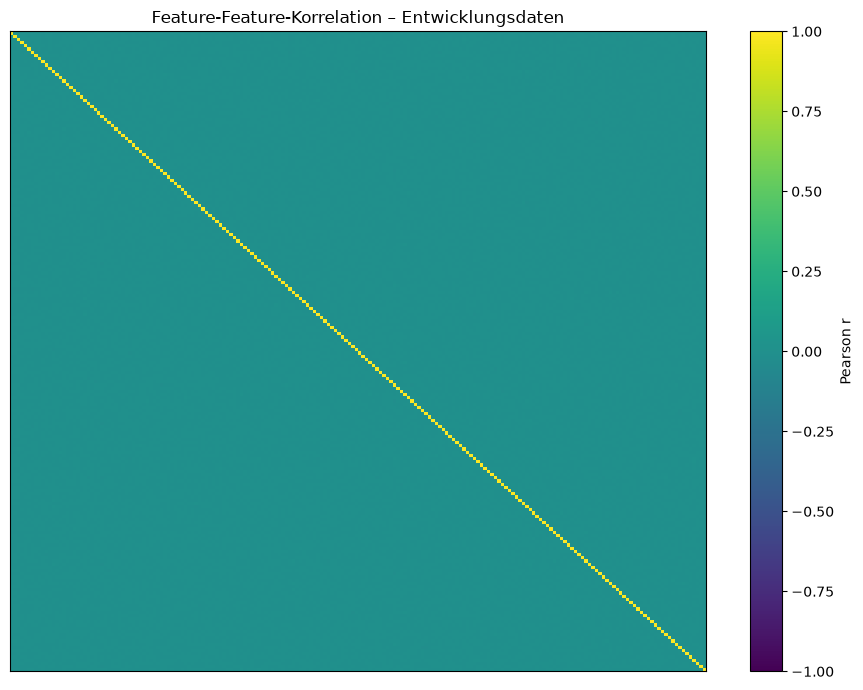

,Feature_A,Feature_B,Korrelation,|r|
5339,var_26,var_139,-0.0111,0.0111
10748,var_53,var_148,-0.0107,0.0107
16374,var_81,var_174,0.0107,0.0107
29369,var_146,var_169,0.0106,0.0106
36789,var_183,var_189,0.0103,0.0103
18365,var_91,var_165,-0.0097,0.0097
27970,var_139,var_170,-0.0097,0.0097
7529,var_37,var_129,0.0096,0.0096
16365,var_81,var_165,0.0095,0.0095
5366,var_26,var_166,-0.0093,0.0093


Maximales |r| zwischen Features: 0.0111
→ Die geringe paarweise Korrelation spricht gegen starke lineare Redundanz. PCA wird trotzdem als Dimensionsreduktions-Experiment für kNN/K-Means getestet, weil 200 Dimensionen unabhängig von paarweisen Korrelationen problematisch sein können.


In [ ]:
feature_corr = X_dev.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(feature_corr, vmin=-1, vmax=1, aspect="auto")
ax.set_title("Feature-Feature-Korrelation – Entwicklungsdaten")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

upper = feature_corr.where(
    np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
).stack()

pairs = (
    upper.rename("Korrelation")
    .reset_index()
    .rename(columns={"level_0": "Feature_A", "level_1": "Feature_B"})
)
pairs["|r|"] = pairs["Korrelation"].abs()
top_pairs = pairs.nlargest(10, "|r|")
display(top_pairs)

print(f"Maximales |r| zwischen Features: {pairs['|r|'].max():.4f}")
print(
    "→ Die geringe paarweise Korrelation spricht gegen starke lineare Redundanz. "
    "PCA wird trotzdem als Dimensionsreduktions-Experiment für kNN/K-Means getestet, "
    "weil 200 Dimensionen unabhängig von paarweisen Korrelationen problematisch sein können."
)


## 11. Statistische Ausreißer: müssen wir sofort eingreifen?

**Frage:** Sind Ausreißer so häufig, dass eine pauschale Bereinigung gerechtfertigt wäre?

Wegen der anonymisierten Features werden Ausreißer nicht automatisch als fehlerhaft interpretiert.


In [ ]:
q1 = X_dev.quantile(0.25)
q3 = X_dev.quantile(0.75)
iqr = q3 - q1

outlier_share = pd.Series({
    c: (
        (X_dev[c] < q1[c] - 1.5 * iqr[c]) |
        (X_dev[c] > q3[c] + 1.5 * iqr[c])
    ).mean()
    for c in X_dev.columns
}).sort_values(ascending=False)

display((outlier_share.head(10) * 100).rename("Ausreißeranteil [%]").to_frame())

print(f"Höchster IQR-Ausreißeranteil: {outlier_share.max():.2%}")
print(
    "→ Kein Hinweis auf ein massives Ausreißerproblem. "
    "Für XGBoost vorerst keine Behandlung; bei kNN/K-Means später prüfen, "
    "ob robuste Skalierung oder Capping die Distanzstruktur verbessert."
)


,Ausreißeranteil [%]
var_179,0.7631
var_44,0.5750
var_93,0.4469
var_146,0.4094
var_192,0.3575
var_31,0.3206
var_133,0.3000
var_105,0.2919
var_38,0.2556
var_193,0.2462


Höchster IQR-Ausreißeranteil: 0.76%
→ Kein Hinweis auf ein massives Ausreißerproblem. Für XGBoost vorerst keine Behandlung; bei kNN/K-Means später prüfen, ob robuste Skalierung oder Capping die Distanzstruktur verbessert.


# 12. EDA-Fazit: konkrete Konsequenzen

| Befund | Konsequenz |
|---|---|
| keine Missing/Inf-Werte in den Entwicklungsdaten | keine Imputation für die Baseline nötig |
| 200 kontinuierliche numerische Features + binäres Target | modellabhängige numerische Vorverarbeitung |
| ca. 10 % positive Klasse | stratifizierte CV; ROC-AUC + PR-AUC |
| stark unterschiedliche Feature-Skalen | Scaling für kNN/K-Means gezielt untersuchen |
| Unterschiede in Schiefe/IQR | StandardScaler gegen robustere Variante prüfen |
| geringe Feature-Feature-Korrelation | kaum lineare Redundanz |
| 200 Dimensionen | PCA für Distanzverfahren trotzdem als Experiment testen |
| einzelne Features nur mäßig trennend | Hypothese: Kombination vieler Features relevant |
| Ausreißeranteile klein | keine pauschale Entfernung; modellabhängig prüfen |
| `float32` reduziert RAM deutlich | für rechenintensive Schritte verwenden |

### Arbeitshypothesen
- **kNN:** `StandardScaler` und ggf. robuste Skalierung/PCA vergleichen; 200 Dimensionen können problematisch sein.
- **K-Means:** Scaling erforderlich; mehrere `k` vergleichen; `target` niemals beim Fit verwenden, sondern erst zur Interpretation.
- **XGBoost:** kein Scaling erforderlich; nichtlineare Interaktionen vieler schwacher Features können genutzt werden.
- **Target-basierte Feature-Rankings:** nur explorativ; eine spätere Feature-Selektion muss innerhalb der CV-Folds erfolgen.

Damit ist XGBoost ein sinnvoller erster überwacht lernender Hauptalgorithmus.


# 13. Äußere 5-Fold Stratified Cross-Validation für XGBoost

## 13.1 Äußere Folds ausschließlich innerhalb der Entwicklungsdaten

Der finale Holdout bleibt vollständig außen vor.

`StratifiedKFold` hält den Anteil von `target=True` in jedem äußeren Fold ungefähr konstant. Der **äußere Validation-Fold dient ausschließlich der Evaluation** und wird weder für Early Stopping noch für andere Modellentscheidungen verwendet.


In [ ]:
from sklearn.model_selection import StratifiedKFold

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_info = []

for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_dev, y_dev), start=1):
    y_fold_train = y_dev.iloc[train_idx]
    y_fold_val = y_dev.iloc[val_idx]

    fold_info.append({
        "Fold": fold,
        "Outer Train n": len(train_idx),
        "Outer Train True-Anteil [%]": 100 * y_fold_train.mean(),
        "Outer Validation n": len(val_idx),
        "Outer Validation True-Anteil [%]": 100 * y_fold_val.mean()
    })

fold_table = pd.DataFrame(fold_info)
display(fold_table)


,Fold,Outer Train n,Outer Train True-Anteil [%],Outer Validation n,Outer Validation True-Anteil [%]
0,1,128000,10.0492,32000,10.0469
1,2,128000,10.0492,32000,10.0469
2,3,128000,10.0484,32000,10.0500
3,4,128000,10.0484,32000,10.0500
4,5,128000,10.0484,32000,10.0500


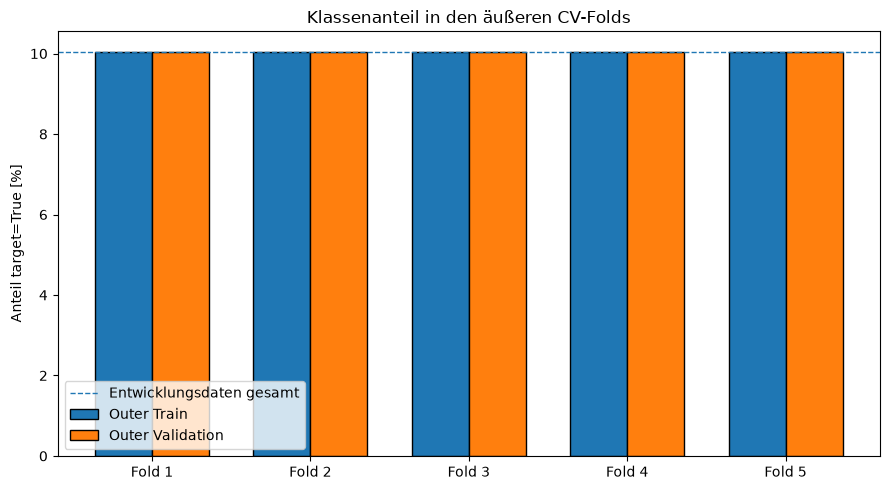

In [ ]:
x = np.arange(len(fold_table))
width = 0.36

plt.figure(figsize=(9, 5))
plt.bar(
    x - width/2,
    fold_table["Outer Train True-Anteil [%]"],
    width,
    label="Outer Train",
    edgecolor="black"
)
plt.bar(
    x + width/2,
    fold_table["Outer Validation True-Anteil [%]"],
    width,
    label="Outer Validation",
    edgecolor="black"
)

plt.axhline(
    100 * y_dev.mean(),
    linestyle="--",
    linewidth=1,
    label="Entwicklungsdaten gesamt"
)
plt.xticks(x, [f"Fold {f}" for f in fold_table["Fold"]])
plt.ylabel("Anteil target=True [%]")
plt.title("Klassenanteil in den äußeren CV-Folds")
plt.legend()
plt.tight_layout()
plt.show()


## 13.2 XGBoost-Baseline: Early Stopping strikt innerhalb des äußeren Trainingsfolds

Für jeden äußeren Fold werden zwei Trainingsschritte durchgeführt:

1. **Baumzahl bestimmen:** Der äußere Trainingsfold wird nochmals stratifiziert in ein inneres Training und ein inneres Early-Stopping-Set. Nur dieses innere Set steuert `best_iteration`.
2. **Äußeres Modell neu trainieren:** Mit der so bestimmten Baumzahl wird ein frisches XGBoost-Modell auf dem **gesamten äußeren Trainingsfold** trainiert.
3. **Nur Evaluation:** Erst danach wird auf dem bis dahin unberührten äußeren Validation-Fold ROC-AUC und PR-AUC berechnet.

Damit beeinflusst der äußere Validation-Fold keine Modellentscheidung.

### Baseline-Parameter
- `objective="binary:logistic"`: binäre Klassifikation mit Wahrscheinlichkeitsausgabe.
- `tree_method="hist"`: effiziente Baumkonstruktion.
- `learning_rate=0.05`, `max_depth=4`, `min_child_weight=5`: moderate Startkomplexität.
- `subsample=0.80`, `colsample_bytree=0.80`: Regularisierung durch Stichproben.
- `reg_alpha=0`, `reg_lambda=1`: zunächst keine zusätzliche L1-Regularisierung und Standard-L2.
- `importance_type="gain"`: Feature-Importance wird explizit als mittlerer Informationsgewinn interpretiert.
- `n_estimators=3000`: nur Obergrenze für die innere Early-Stopping-Phase.
- `early_stopping_rounds=75`: Stop bei ausbleibender Verbesserung.
- `eval_metric=["aucpr", "auc"]`: beide Rangmetriken werden protokolliert; AUC steht zuletzt und steuert das Early Stopping.
- kein Scaling für XGBoost.

`scale_pos_weight` bleibt für die Baseline bewusst deaktiviert und wird später als gezielte Variante verglichen.


In [ ]:
try:
    import xgboost
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost ist nicht installiert. Im aktuell verwendeten Notebook-Kernel ausführen: "
        "%pip install xgboost"
    ) from exc

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

print("xgboost:", xgboost.__version__)

NEG_POS_RATIO = (y_dev == 0).sum() / (y_dev == 1).sum()
print(f"Negativ/Positiv-Verhältnis in den Entwicklungsdaten: {NEG_POS_RATIO:.3f}")
print("→ Dieser Wert wird später als Kandidat für scale_pos_weight getestet, nicht in der Baseline.")

N_ESTIMATORS_CAP = 3000
EARLY_STOPPING_ROUNDS = 75
INNER_EARLY_STOPPING_SIZE = 0.15

base_xgb_params = dict(
    objective="binary:logistic",
    tree_method="hist",
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    importance_type="gain",
    random_state=RANDOM_STATE,
    n_jobs=-1
)


xgboost: 3.4.0
Negativ/Positiv-Verhältnis in den Entwicklungsdaten: 8.951
→ Dieser Wert wird später als Kandidat für scale_pos_weight getestet, nicht in der Baseline.


In [ ]:
cv_results = []
oof_proba = np.full(len(X_dev), np.nan, dtype="float64")
fold_importances = []

for fold, (outer_train_idx, outer_val_idx) in enumerate(
    outer_cv.split(X_dev, y_dev),
    start=1
):
    print(f"\n===== Outer Fold {fold}/5 =====")

    X_outer_train = X_dev.iloc[outer_train_idx]
    y_outer_train = y_dev.iloc[outer_train_idx]

    X_outer_val = X_dev.iloc[outer_val_idx]
    y_outer_val = y_dev.iloc[outer_val_idx]

    # Innerer Split ausschließlich innerhalb des äußeren Trainingsfolds.
    X_inner_train, X_inner_es, y_inner_train, y_inner_es = train_test_split(
        X_outer_train,
        y_outer_train,
        test_size=INNER_EARLY_STOPPING_SIZE,
        stratify=y_outer_train,
        random_state=RANDOM_STATE + fold
    )

    # Phase 1: Baumzahl ausschließlich mit innerem Early-Stopping-Set bestimmen.
    es_model = XGBClassifier(
        **base_xgb_params,
        n_estimators=N_ESTIMATORS_CAP,
        eval_metric=["aucpr", "auc"],
        early_stopping_rounds=EARLY_STOPPING_ROUNDS
    )

    es_model.fit(
        X_inner_train,
        y_inner_train,
        eval_set=[(X_inner_es, y_inner_es)],
        verbose=200
    )

    best_trees = int(es_model.best_iteration) + 1

    # Phase 2: frisches Modell auf dem vollständigen äußeren Trainingsfold.
    outer_pipeline = Pipeline([
        ("model", XGBClassifier(
            **base_xgb_params,
            n_estimators=best_trees,
            eval_metric=["aucpr", "auc"]
        ))
    ])

    outer_pipeline.fit(X_outer_train, y_outer_train)

    # Phase 3: äußeren Validation-Fold erstmals und ausschließlich evaluieren.
    outer_val_proba = outer_pipeline.predict_proba(X_outer_val)[:, 1]
    oof_proba[outer_val_idx] = outer_val_proba

    fitted_outer_model = outer_pipeline.named_steps["model"]

    fold_roc_auc = roc_auc_score(y_outer_val, outer_val_proba)
    fold_pr_auc = average_precision_score(y_outer_val, outer_val_proba)

    cv_results.append({
        "Fold": fold,
        "ROC-AUC": fold_roc_auc,
        "PR-AUC": fold_pr_auc,
        "Beste Baumanzahl (inneres ES)": best_trees,
        "Inner Train n": len(X_inner_train),
        "Inner ES n": len(X_inner_es),
        "Outer Validation n": len(X_outer_val)
    })

    fold_importances.append(fitted_outer_model.feature_importances_)

    print(
        f"Outer Fold {fold}: ROC-AUC={fold_roc_auc:.4f} | "
        f"PR-AUC={fold_pr_auc:.4f} | "
        f"beste Baumanzahl={best_trees}"
    )

assert not np.isnan(oof_proba).any(), "Nicht alle OOF-Vorhersagen wurden gefüllt."

cv_results = pd.DataFrame(cv_results)
display(cv_results)

cv_summary = pd.DataFrame({
    "Metrik": ["ROC-AUC", "PR-AUC"],
    "Mittelwert": [
        cv_results["ROC-AUC"].mean(),
        cv_results["PR-AUC"].mean()
    ],
    "Standardabweichung": [
        cv_results["ROC-AUC"].std(ddof=1),
        cv_results["PR-AUC"].std(ddof=1)
    ]
})

display(cv_summary)

print(f"OOF ROC-AUC über alle Entwicklungsdaten: {roc_auc_score(y_dev, oof_proba):.4f}")
print(f"OOF PR-AUC über alle Entwicklungsdaten:  {average_precision_score(y_dev, oof_proba):.4f}")

median_best_trees = int(np.median(cv_results["Beste Baumanzahl (inneres ES)"]))
print(f"Median der per innerem Early Stopping gewählten Baumanzahl: {median_best_trees}")

if (cv_results["Beste Baumanzahl (inneres ES)"] >= N_ESTIMATORS_CAP).any():
    print(
        "Hinweis: Mindestens ein innerer Lauf erreichte die n_estimators-Obergrenze. "
        "Dann sollte die Obergrenze erhöht oder die Lernrate neu geprüft werden."
    )



===== Outer Fold 1/5 =====
[0]	validation_0-aucpr:0.16065	validation_0-auc:0.60735
[200]	validation_0-aucpr:0.50250	validation_0-auc:0.85536
[400]	validation_0-aucpr:0.55056	validation_0-auc:0.87749
[600]	validation_0-aucpr:0.57269	validation_0-auc:0.88601
[800]	validation_0-aucpr:0.58349	validation_0-auc:0.88994
[1000]	validation_0-aucpr:0.58954	validation_0-auc:0.89186
[1200]	validation_0-aucpr:0.59231	validation_0-auc:0.89305
[1400]	validation_0-aucpr:0.59316	validation_0-auc:0.89338
[1600]	validation_0-aucpr:0.59326	validation_0-auc:0.89365
[1606]	validation_0-aucpr:0.59303	validation_0-auc:0.89361
Outer Fold 1: ROC-AUC=0.8938 | PR-AUC=0.6014 | beste Baumanzahl=1532

===== Outer Fold 2/5 =====
[0]	validation_0-aucpr:0.17892	validation_0-auc:0.63293
[200]	validation_0-aucpr:0.51830	validation_0-auc:0.85872
[400]	validation_0-aucpr:0.57242	validation_0-auc:0.88124
[600]	validation_0-aucpr:0.59137	validation_0-auc:0.88872
[800]	validation_0-aucpr:0.60191	validation_0-auc:0.89257
[100

,Fold,ROC-AUC,PR-AUC,Beste Baumanzahl (inneres ES),Inner Train n,Inner ES n,Outer Validation n
0,1,0.8938,0.6014,1532,108800,19200,32000
1,2,0.8965,0.6009,1289,108800,19200,32000
2,3,0.8931,0.5945,1575,108800,19200,32000
3,4,0.8910,0.5978,1713,108800,19200,32000
4,5,0.8955,0.5959,1392,108800,19200,32000


,Metrik,Mittelwert,Standardabweichung
0,ROC-AUC,0.8940,0.0022
1,PR-AUC,0.5981,0.0030


OOF ROC-AUC über alle Entwicklungsdaten: 0.8938
OOF PR-AUC über alle Entwicklungsdaten:  0.5979
Median der per innerem Early Stopping gewählten Baumanzahl: 1532


## 13.3 CV-Ergebnisse professionell visualisieren

Die Balken zeigen den **Mittelwert über fünf äußere Folds**, die Fehlerbalken die Standardabweichung. Die einzelnen Fold-Punkte bleiben sichtbar, damit sowohl zentrale Tendenz als auch Streuung nachvollziehbar sind.


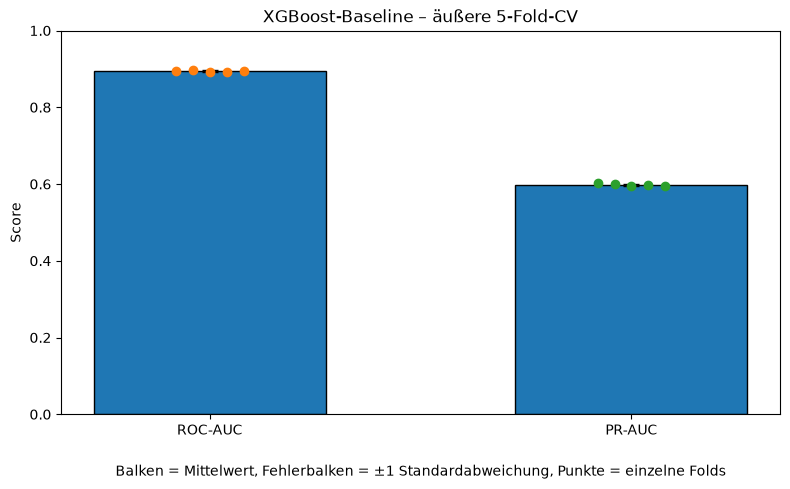

In [ ]:
metrics = ["ROC-AUC", "PR-AUC"]
means = [cv_results[m].mean() for m in metrics]
stds = [cv_results[m].std(ddof=1) for m in metrics]

x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    x,
    means,
    yerr=stds,
    capsize=6,
    width=0.55,
    edgecolor="black"
)

for i, metric in enumerate(metrics):
    jitter = np.linspace(-0.08, 0.08, len(cv_results))
    ax.scatter(
        np.full(len(cv_results), i) + jitter,
        cv_results[metric],
        zorder=3
    )

ax.set_xticks(x, metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("XGBoost-Baseline – äußere 5-Fold-CV")
ax.text(
    0.5,
    -0.16,
    "Balken = Mittelwert, Fehlerbalken = ±1 Standardabweichung, Punkte = einzelne Folds",
    transform=ax.transAxes,
    ha="center"
)
plt.tight_layout()
plt.show()


## 13.4 Welche Features nutzt XGBoost stabil über die äußeren Folds?

Die XGBoost-Importance wird explizit als **Gain-Importance** definiert und über die fünf vollständig neu trainierten äußeren Modelle gemittelt.

Die Fehlerbalken zeigen die Streuung der Gain-Importance zwischen den Folds. Die Importances sind modellabhängig und **keine kausale Erklärung**.


,Gain-Importance Mittel,Gain-Importance Std,|Cohen's d|,|Pearson|
var_81,0.0195,0.0014,0.2671,0.0800
var_139,0.0149,0.0015,0.2438,0.0731
var_12,0.0139,0.0007,0.2338,0.0701
var_53,0.0122,0.0008,0.2118,0.0636
var_110,0.0119,0.0005,0.2155,0.0647
var_26,0.0118,0.0009,0.2088,0.0627
var_6,0.0109,0.0004,0.2309,0.0693
var_146,0.0108,0.0009,0.2184,0.0655
var_80,0.0105,0.0008,0.1931,0.0579
var_166,0.0104,0.0006,0.1978,0.0593


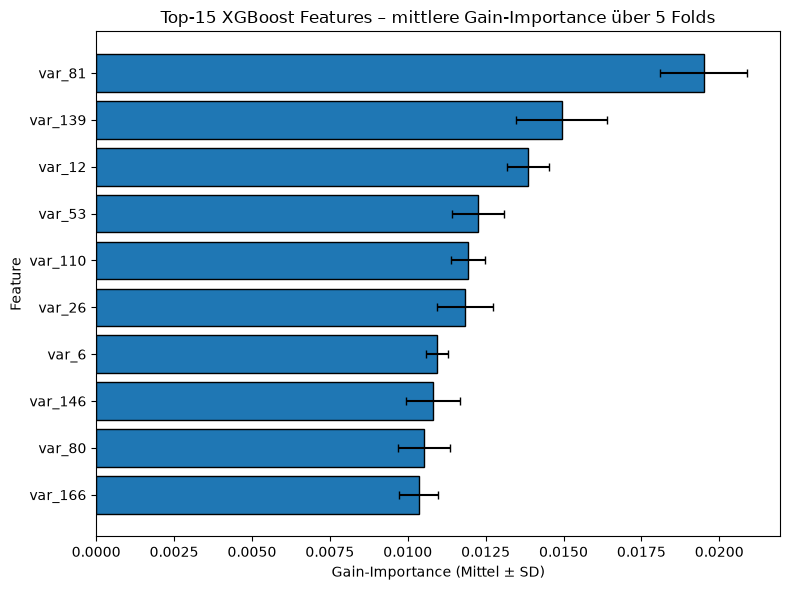

In [ ]:
importance_array = np.vstack(fold_importances)

importance_mean = pd.Series(
    importance_array.mean(axis=0),
    index=X_dev.columns,
    name="Gain-Importance Mittel"
)

importance_std = pd.Series(
    importance_array.std(axis=0, ddof=1),
    index=X_dev.columns,
    name="Gain-Importance Std"
)

top_features = importance_mean.sort_values(ascending=False).head(10).index

importance_table = pd.concat(
    [
        importance_mean,
        importance_std,
        assoc["abs_Cohens_d"].rename("|Cohen's d|"),
        assoc["abs_Pearson"].rename("|Pearson|")
    ],
    axis=1
).loc[top_features]

display(importance_table)

plot_table = importance_table.sort_values("Gain-Importance Mittel")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    plot_table.index,
    plot_table["Gain-Importance Mittel"],
    xerr=plot_table["Gain-Importance Std"],
    capsize=3,
    edgecolor="black"
)
ax.set_title("Top-15 XGBoost Features – mittlere Gain-Importance über 5 Folds")
ax.set_xlabel("Gain-Importance (Mittel ± SD)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


# 14. Finaler Holdout bleibt bewusst gesperrt

Der prospektiv gesperrte Holdout wird **jetzt nicht ausgewertet**.

Erst nach:
1. Baseline-CV,
2. gezielten Hyperparameter-Varianten,
3. Vergleich mit `scale_pos_weight`,
4. Learning-Curve-Experiment,
5. ggf. Threshold-Wahl aus **OOF-Vorhersagen**,
6. Vergleich mit den anderen Modellen

wird ein finales Modell auf allen Entwicklungsdaten trainiert und **genau einmal** auf `X_final_holdout` / `y_final_holdout` evaluiert.

Damit beeinflussen Holdout-Metriken die Modellauswahl ab diesem methodischen Reset nicht mehr.


In [ ]:
print("Finaler Holdout: GESPERRT")
print(f"Anzahl Holdout-Beobachtungen: {len(X_final_holdout):,}")
print("Keine Zielverteilung, keine Vorhersagen und keine Metriken werden hier berechnet.")


Finaler Holdout: GESPERRT
Anzahl Holdout-Beobachtungen: 40,000
Keine Zielverteilung, keine Vorhersagen und keine Metriken werden hier berechnet.


# 15. Nächste gezielte Experimente

Die nächsten Schritte werden jeweils gegen die äußere 5-Fold-Baseline verglichen:

1. **Klassen-Gewichtung:** ungewichtete Baseline vs. `scale_pos_weight ≈ Negativ/Positiv-Verhältnis`.
2. **Baumkomplexität:** z. B. `max_depth` 3/4/5/6 und `min_child_weight` 1/5/10.
3. **Sampling-Regularisierung:** `subsample` 0.7/0.8/1.0 und `colsample_bytree` 0.5/0.7/0.8/1.0.
4. **Lernrate:** z. B. 0.03/0.05/0.10, jeweils mit ausreichend hoher Baumobergrenze und innerem Early Stopping.
5. **Regularisierung:** `reg_alpha` und `reg_lambda` erst danach gezielt variieren.
6. **Learning Curve:** prüfen, ob kleinere Trainingsmengen bereits ähnliche CV-Leistung erreichen.
7. **Threshold-Tuning:** Precision/Recall/F1 ausschließlich aus **OOF-Wahrscheinlichkeiten**, niemals am finalen Holdout optimieren.
8. **kNN:** Scaling + robuste Skalierung + PCA als Pipeline-Varianten.
9. **K-Means:** Scaling, mehrere `k`, Silhouette/Elbow; `target` erst nach dem Fit zur Interpretation.
10. **Feature-Selektion:** falls target-basierte Rankings verwendet werden, ausschließlich innerhalb der Trainingsfolds.
11. **Finale Evaluation:** erst nach Modellwahl genau einmal auf dem gesperrten Holdout.

So bleibt der Arbeitsprozess iterativ, nachvollziehbar und methodisch sauber.


## 16.5 Nächste Schritte für kNN-Varianten (optional)

Die Baseline mit `StandardScaler` und verschiedenen k-Werten wurde getestet. Mögliche Varianten:

1. **RobustScaler:** Weniger empfindlich gegen Ausreißer als StandardScaler.
2. **PCA-Vorverarbeitung:** Reduktion von 200 auf z. B. 20–50 Komponenten vor kNN (bei hochdimensionalen Daten kann PCA den Fluch der Dimensionalität mildern).
3. **Gewichtetes kNN:** `weights="distance"` statt `"uniform"` → nähere Nachbarn beeinflussen mehr.
4. **Metrik-Varianten:** z. B. Manhattan-Distanz (`metric="manhattan"`).
5. **Vergleich mit äußerem Holdout:** Erst nach Modellwahl.



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# kNN-Parameter (Baseline)
KNN_K_VALUES = [3, 5, 7, 11, 15, 21]

print("kNN-Baseline-Parameter:")
print(f"  k-Werte zum Testen: {KNN_K_VALUES}")
print(f"  Distanzmetrik: Euklid (Standard)")
print(f"  Preprocessing: StandardScaler")
print(f"  Äußere CV: StratifiedKFold (5 Splits)")
print(f"  Inneres Early Stopping: entfällt (kNN hat keine Baumanzahl)")
print()
print("Strategie:")
print("  1. Für jeden äußeren Fold und jeden k-Wert")
print("  2. StandardScaler fit nur auf äußerem Trainingsfold")
print("  3. Skalierte Daten für Modellerstellung verwenden")
print("  4. ROC-AUC und PR-AUC nur auf äußerem Validation-Fold berechnen")
print("  5. Am Ende: besten k-Wert anhand CV-Mittelwert wählen")



kNN-Baseline-Parameter:
  k-Werte zum Testen: [3, 5, 7, 11, 15, 21]
  Distanzmetrik: Euklid (Standard)
  Preprocessing: StandardScaler
  Äußere CV: StratifiedKFold (5 Splits)
  Inneres Early Stopping: entfällt (kNN hat keine Baumanzahl)

Strategie:
  1. Für jeden äußeren Fold und jeden k-Wert
  2. StandardScaler fit nur auf äußerem Trainingsfold
  3. Skalierte Daten für Modellerstellung verwenden
  4. ROC-AUC und PR-AUC nur auf äußerem Validation-Fold berechnen
  5. Am Ende: besten k-Wert anhand CV-Mittelwert wählen


## 16.2 kNN mit verschiedenen k-Werten über äußere 5-Fold-CV

Für jeden äußeren Fold:
1. StandardScaler an äußerem Trainingsfold fitten
2. Skalierte Trainings- und Validationsdaten für kNN verwenden
3. ROC-AUC und PR-AUC berechnen

Keine inneren CV-Schleifen nötig, da kNN keine hyperparameter wie Baumanzahl braucht, die gelernt werden müssen. Die k-Werte werden direkt über äußere Folds verglichen.

In [ ]:
knn_results = []

for fold, (outer_train_idx, outer_val_idx) in enumerate(
    outer_cv.split(X_dev, y_dev),
    start=1
):
    print(f"\n===== kNN Outer Fold {fold}/5 =====")

    X_outer_train = X_dev.iloc[outer_train_idx]
    y_outer_train = y_dev.iloc[outer_train_idx]

    X_outer_val = X_dev.iloc[outer_val_idx]
    y_outer_val = y_dev.iloc[outer_val_idx]

    # StandardScaler fit nur auf äußerem Trainingsfold
    scaler = StandardScaler()
    X_outer_train_scaled = scaler.fit_transform(X_outer_train)
    X_outer_val_scaled = scaler.transform(X_outer_val)

    # Für jeden k-Wert Modell trainieren und evaluieren
    for k in KNN_K_VALUES:
        knn_model = KNeighborsClassifier(
            n_neighbors=k,
            metric="euclidean",
            n_jobs=-1
        )

        knn_model.fit(X_outer_train_scaled, y_outer_train)

        # Vorhersagen auf Validation-Fold
        val_proba = knn_model.predict_proba(X_outer_val_scaled)[:, 1]

        fold_roc_auc = roc_auc_score(y_outer_val, val_proba)
        fold_pr_auc = average_precision_score(y_outer_val, val_proba)

        knn_results.append({
            "Fold": fold,
            "k": k,
            "ROC-AUC": fold_roc_auc,
            "PR-AUC": fold_pr_auc,
            "Outer Train n": len(X_outer_train),
            "Outer Validation n": len(X_outer_val)
        })

        print(f"  k={k:2d}: ROC-AUC={fold_roc_auc:.4f} | PR-AUC={fold_pr_auc:.4f}")

knn_results_df = pd.DataFrame(knn_results)
display(knn_results_df.head(15))


===== kNN Outer Fold 1/5 =====
  k= 3: ROC-AUC=0.5331 | PR-AUC=0.1127
  k= 5: ROC-AUC=0.5528 | PR-AUC=0.1202
  k= 7: ROC-AUC=0.5630 | PR-AUC=0.1259
  k=11: ROC-AUC=0.5842 | PR-AUC=0.1327
  k=15: ROC-AUC=0.6010 | PR-AUC=0.1427
  k=21: ROC-AUC=0.6229 | PR-AUC=0.1579

===== kNN Outer Fold 2/5 =====
  k= 3: ROC-AUC=0.5325 | PR-AUC=0.1120
  k= 5: ROC-AUC=0.5520 | PR-AUC=0.1196
  k= 7: ROC-AUC=0.5613 | PR-AUC=0.1243
  k=11: ROC-AUC=0.5818 | PR-AUC=0.1325
  k=15: ROC-AUC=0.5989 | PR-AUC=0.1438
  k=21: ROC-AUC=0.6232 | PR-AUC=0.1595

===== kNN Outer Fold 3/5 =====
  k= 3: ROC-AUC=0.5264 | PR-AUC=0.1085
  k= 5: ROC-AUC=0.5381 | PR-AUC=0.1122
  k= 7: ROC-AUC=0.5552 | PR-AUC=0.1176
  k=11: ROC-AUC=0.5759 | PR-AUC=0.1259
  k=15: ROC-AUC=0.5936 | PR-AUC=0.1361
  k=21: ROC-AUC=0.6189 | PR-AUC=0.1475

===== kNN Outer Fold 4/5 =====
  k= 3: ROC-AUC=0.5235 | PR-AUC=0.1084
  k= 5: ROC-AUC=0.5385 | PR-AUC=0.1132
  k= 7: ROC-AUC=0.5541 | PR-AUC=0.1199
  k=11: ROC-AUC=0.5817 | PR-AUC=0.1343
  k=15: ROC-AU

,Fold,k,ROC-AUC,PR-AUC,Outer Train n,Outer Validation n
0,1,3,0.5331,0.1127,128000,32000
1,1,5,0.5528,0.1202,128000,32000
2,1,7,0.5630,0.1259,128000,32000
3,1,11,0.5842,0.1327,128000,32000
4,1,15,0.6010,0.1427,128000,32000
5,1,21,0.6229,0.1579,128000,32000
6,2,3,0.5325,0.1120,128000,32000
7,2,5,0.5520,0.1196,128000,32000
8,2,7,0.5613,0.1243,128000,32000
9,2,11,0.5818,0.1325,128000,32000


## 16.3 kNN-Ergebnisse: beste k-Werte über CV

In [ ]:
# Aggregation nach k
knn_by_k = knn_results_df.groupby("k")[["ROC-AUC", "PR-AUC"]].agg(["mean", "std"])
knn_by_k = knn_by_k.round(4)
display(knn_by_k)

# Beste k nach ROC-AUC
best_k_roc = knn_results_df.groupby("k")["ROC-AUC"].mean().idxmax()
best_roc_score = knn_results_df.groupby("k")["ROC-AUC"].mean().max()

best_k_pr = knn_results_df.groupby("k")["PR-AUC"].mean().idxmax()
best_pr_score = knn_results_df.groupby("k")["PR-AUC"].mean().max()

print(f"Beste k nach ROC-AUC: k={best_k_roc} (Score={best_roc_score:.4f})")
print(f"Beste k nach PR-AUC:  k={best_k_pr} (Score={best_pr_score:.4f})")

ROC-AUC        PR-AUC       
      mean    std   mean    std
k                              
3   0.5296 0.0044 0.1107 0.0021
5   0.5461 0.0073 0.1168 0.0038
7   0.5584 0.0038 0.1220 0.0033
11  0.5803 0.0033 0.1308 0.0035
15  0.5981 0.0028 0.1410 0.0033
21  0.6201 0.0028 0.1543 0.0049

Beste k nach ROC-AUC: k=21 (Score=0.6201)
Beste k nach PR-AUC:  k=21 (Score=0.1543)


## 16.4 Vergleich: kNN vs. XGBoost

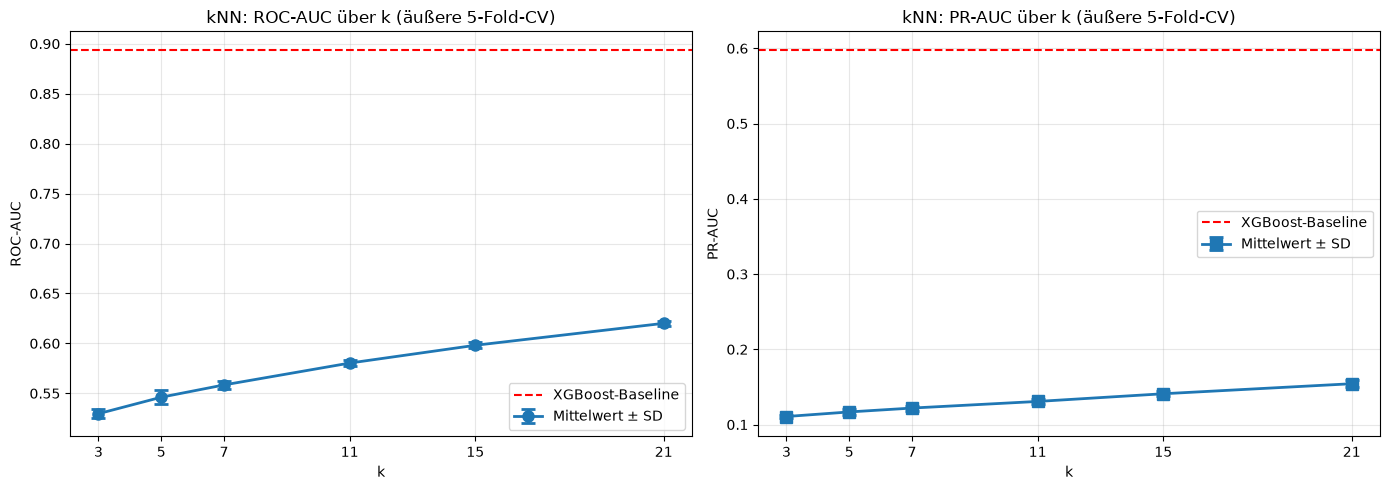

In [ ]:
# Visualisierung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC nach k
roc_mean = knn_results_df.groupby("k")["ROC-AUC"].mean()
roc_std = knn_results_df.groupby("k")["ROC-AUC"].std()

ax1.errorbar(
    roc_mean.index,
    roc_mean.values,
    yerr=roc_std.values,
    marker="o",
    capsize=5,
    capthick=2,
    linewidth=2,
    markersize=8,
    label="Mittelwert ± SD"
)
ax1.axhline(cv_summary.loc[0, "Mittelwert"], color="red", linestyle="--", label="XGBoost-Baseline")
ax1.set_xlabel("k")
ax1.set_ylabel("ROC-AUC")
ax1.set_title("kNN: ROC-AUC über k (äußere 5-Fold-CV)")
ax1.grid(alpha=0.3)
ax1.legend()
ax1.set_xticks(KNN_K_VALUES)

# PR-AUC nach k
pr_mean = knn_results_df.groupby("k")["PR-AUC"].mean()
pr_std = knn_results_df.groupby("k")["PR-AUC"].std()

ax2.errorbar(
    pr_mean.index,
    pr_mean.values,
    yerr=pr_std.values,
    marker="s",
    capsize=5,
    capthick=2,
    linewidth=2,
    markersize=8,
    label="Mittelwert ± SD"
)
ax2.axhline(cv_summary.loc[1, "Mittelwert"], color="red", linestyle="--", label="XGBoost-Baseline")
ax2.set_xlabel("k")
ax2.set_ylabel("PR-AUC")
ax2.set_title("kNN: PR-AUC über k (äußere 5-Fold-CV)")
ax2.grid(alpha=0.3)
ax2.legend()
ax2.set_xticks(KNN_K_VALUES)

plt.tight_layout()
plt.show()

## 16.5 Nächste Schritte für kNN-Varianten (optional)

Die Baseline mit `StandardScaler` und verschiedenen k-Werten wurde getestet. Mögliche Varianten:

1. **RobustScaler:** Weniger empfindlich gegen Ausreißer als StandardScaler.
2. **PCA-Vorverarbeitung:** Reduktion von 200 auf z. B. 20–50 Komponenten vor kNN (bei hochdimensionalen Daten kann PCA den Fluch der Dimensionalität mildern).
3. **Gewichtetes kNN:** `weights="distance"` statt `"uniform"` → nähere Nachbarn beeinflussen mehr.
4. **Metrik-Varianten:** z. B. Manhattan-Distanz (`metric="manhattan"`).
5. **Vergleich mit äußerem Holdout:** Erst nach Modellwahl.

In [ ]:
comparison = pd.DataFrame({
    "Modell": ["XGBoost", f"kNN (k={best_k_roc})", f"kNN (k={best_k_pr})"],
    "ROC-AUC Mittel": [
        cv_summary.loc[0, "Mittelwert"],
        knn_results_df.groupby("k")["ROC-AUC"].mean()[best_k_roc],
        knn_results_df.groupby("k")["ROC-AUC"].mean()[best_k_pr]
    ],
    "ROC-AUC Std": [
        cv_summary.loc[0, "Standardabweichung"],
        knn_results_df.groupby("k")["ROC-AUC"].std()[best_k_roc],
        knn_results_df.groupby("k")["ROC-AUC"].std()[best_k_pr]
    ],
    "PR-AUC Mittel": [
        cv_summary.loc[1, "Mittelwert"],
        knn_results_df.groupby("k")["PR-AUC"].mean()[best_k_roc],
        knn_results_df.groupby("k")["PR-AUC"].mean()[best_k_pr]
    ],
    "PR-AUC Std": [
        cv_summary.loc[1, "Standardabweichung"],
        knn_results_df.groupby("k")["PR-AUC"].std()[best_k_roc],
        knn_results_df.groupby("k")["PR-AUC"].std()[best_k_pr]
    ]
})

display(comparison)

print("\nInterpretation:")
print(f"XGBoost ROC-AUC:     {cv_summary.loc[0, 'Mittelwert']:.4f} ± {cv_summary.loc[0, 'Standardabweichung']:.4f}")
print(f"kNN (k={best_k_roc}) ROC-AUC: {knn_results_df.groupby('k')['ROC-AUC'].mean()[best_k_roc]:.4f} ± {knn_results_df.groupby('k')['ROC-AUC'].std()[best_k_roc]:.4f}")
print()
print(f"XGBoost PR-AUC:      {cv_summary.loc[1, 'Mittelwert']:.4f} ± {cv_summary.loc[1, 'Standardabweichung']:.4f}")
print(f"kNN (k={best_k_pr}) PR-AUC:  {knn_results_df.groupby('k')['PR-AUC'].mean()[best_k_pr]:.4f} ± {knn_results_df.groupby('k')['PR-AUC'].std()[best_k_pr]:.4f}")

,Modell,ROC-AUC Mittel,ROC-AUC Std,PR-AUC Mittel,PR-AUC Std
0,XGBoost,0.8940,0.0022,0.5981,0.0030
1,kNN (k=21),0.6201,0.0028,0.1543,0.0049
2,kNN (k=21),0.6201,0.0028,0.1543,0.0049



Interpretation:
XGBoost ROC-AUC:     0.8940 ± 0.0022
kNN (k=21) ROC-AUC: 0.6201 ± 0.0028

XGBoost PR-AUC:      0.5981 ± 0.0030
kNN (k=21) PR-AUC:  0.1543 ± 0.0049


# 16. k-Nearest-Neighbors (kNN) – äußere 5-Fold Stratified Cross-Validation

## 16.1 Preprocessing für kNN

kNN ist ein **distanzbasiertes Verfahren** und verlangt anders als XGBoost **zwingend Skalierung**, da es Features mit größerer Streuung sonst über-gewichtet.

Aus der EDA wissen wir:
- Max/Min Standardabweichung der Features: **~1.3x** (beträchtlicher Unterschied)
- Keine Missing Values
- Unterschiede in Schiefe/IQR → `StandardScaler` als Baseline

**Preprocessing-Strategie:**
- `StandardScaler`: Mittelwert=0, Varianz=1 pro Feature (unabhängig von Ausreißern)
- **Fit ausschließlich auf dem inneren Trainingsfold** um Data Leakage zu vermeiden
- Dasselbe Pattern wie bei XGBoost: inner train → inner ES → outer validation

Optional später: `RobustScaler` (weniger empfindlich gegen Ausreißer) als Vergleich; PCA zur Dimensionsreduktion.



# 17. K-Means Clustering – Explorative Analyse

K-Means ist ein **unüberwachter** Algorithmus zur Datenpartitionierung:
- Ziel: Finde $k$ Cluster, die intern homogen und extern getrennt sind
- Nützlich zur **Datenstruktur-Exploration**: Gibt es natürliche Gruppen?
- **Kein direktes Klassifikations-Modell** wie kNN/XGBoost, aber interessant zur Feature-Generierung

Strategie:
1. **Elbow-Methode**: Inertia vs. k → Inflection Point = optimales k
2. **Silhouette-Score**: Durchschnittliche Cluster-Kohäsion (-1 bis +1)
3. **Target-Analyse**: Wie verteilen sich positive/negative Samples über Cluster?

## 17.1 Preprocessing & K-Means Konfiguration

**Skalierung**: Wie bei kNN braucht K-Means normalisierte Features (distanzbasiert).
- StandardScaler: Mittelwert=0, Varianz=1
- **Fit ausschließlich auf X_dev** (keine CV-Schleifen nötig, da unüberwacht)

**K-Werte zum Testen**: 2, 3, 4, 5, 7, 10, 15, 20, 25, 30
- Start: kleine k (2-5)
- Mid: größere k (7-15)
- End: sehr große k (20-30) → meist überssegmentiert

**Metriken**:
- **Inertia**: Summe der Distanzen zu Cluster-Zentren (je kleiner desto besser)
- **Silhouette-Score**: Wie gut passt jeder Sample zu seinem Cluster? (-1 bis +1, höher besser)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# K-Means Konfiguration
KMEANS_K_VALUES = [2, 3, 4, 5, 7, 10, 15, 20, 25, 30]
KMEANS_RANDOM_STATE = RANDOM_STATE
KMEANS_N_INIT = 10  # Mehrere Initialisierungen für Stabilität

print("K-Means Konfiguration:")
print(f"  k-Werte zum Testen: {KMEANS_K_VALUES}")
print(f"  Skalierung: StandardScaler")
print(f"  Daten: X_dev ({X_dev.shape[0]} Samples, {X_dev.shape[1]} Features)")
print(f"  Metriken: Inertia + Silhouette-Score")
print()

# Preprocessing: StandardScaler auf X_dev
scaler_kmeans = StandardScaler()
X_dev_scaled = scaler_kmeans.fit_transform(X_dev)

print(f"Skalierte Daten: {X_dev_scaled.shape}")
print(f"  Mittelwert pro Feature (sollte ~0): {X_dev_scaled.mean(axis=0)[:5].round(6)}")
print(f"  Std pro Feature (sollte ~1): {X_dev_scaled.std(axis=0)[:5].round(6)}")

K-Means Konfiguration:
  k-Werte zum Testen: [2, 3, 4, 5, 7, 10, 15, 20, 25, 30]
  Skalierung: StandardScaler
  Daten: X_dev (160000 Samples, 200 Features)
  Metriken: Inertia + Silhouette-Score

Skalierte Daten: (160000, 200)
  Mittelwert pro Feature (sollte ~0): [ 0. -0. -0. -0. -0.]
  Std pro Feature (sollte ~1): [1. 1. 1. 1. 1.]


## 17.2 Elbow-Methode & Silhouette-Score

In [36]:
kmeans_results = []

print("K-Means Training für verschiedene k-Werte...")
print("=" * 70)

for k in KMEANS_K_VALUES:
    print(f"\nk={k:2d} | ", end="", flush=True)
    
    # K-Means trainieren
    kmeans = KMeans(
        n_clusters=k,
        random_state=KMEANS_RANDOM_STATE,
        n_init=KMEANS_N_INIT,
        verbose=0
    )
    
    cluster_labels = kmeans.fit_predict(X_dev_scaled)
    
    # Metriken berechnen
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_dev_scaled, cluster_labels)
    
    kmeans_results.append({
        "k": k,
        "Inertia": inertia,
        "Silhouette": silhouette,
        "Center Count": len(np.unique(cluster_labels))
    })
    
    print(f"Inertia={inertia:.2e} | Silhouette={silhouette:.4f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
print("\n" + "=" * 70)
display(kmeans_results_df)

K-Means Training für verschiedene k-Werte...

k= 2 | Inertia=3.19e+07 | Silhouette=0.0042

k= 3 | Inertia=3.18e+07 | Silhouette=0.0023

k= 4 | Inertia=3.17e+07 | Silhouette=0.0020

k= 5 | Inertia=3.17e+07 | Silhouette=0.0019

k= 7 | Inertia=3.16e+07 | Silhouette=0.0020

k=10 | Inertia=3.15e+07 | Silhouette=0.0020

k=15 | Inertia=3.14e+07 | Silhouette=0.0021

k=20 | Inertia=3.13e+07 | Silhouette=0.0022

k=25 | Inertia=3.13e+07 | Silhouette=0.0022

k=30 | 

KeyboardInterrupt: 

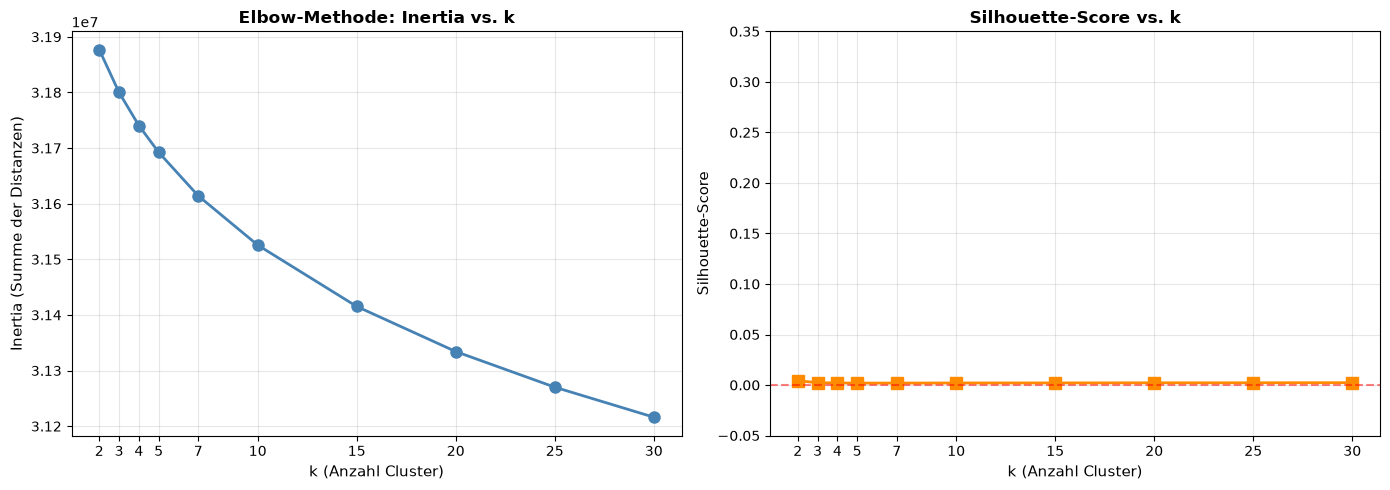


Interpretation:
  Höchster Silhouette-Score: k=2 (Score=0.0042)
  Niedrigste Inertia: k=30 (aber größer k kann Overfitting bedeuten)
  Potentieller Elbow-Punkt: k=3-5 (Abknicken in Inertia-Kurve)


In [32]:
# Visualisierung: Elbow & Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow-Diagramm
ax1.plot(kmeans_results_df["k"], kmeans_results_df["Inertia"], 
         marker="o", linewidth=2, markersize=8, color="steelblue")
ax1.set_xlabel("k (Anzahl Cluster)", fontsize=11)
ax1.set_ylabel("Inertia (Summe der Distanzen)", fontsize=11)
ax1.set_title("Elbow-Methode: Inertia vs. k", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3)
ax1.set_xticks(KMEANS_K_VALUES)

# Silhouette-Score
ax2.plot(kmeans_results_df["k"], kmeans_results_df["Silhouette"],
         marker="s", linewidth=2, markersize=8, color="darkorange")
ax2.set_xlabel("k (Anzahl Cluster)", fontsize=11)
ax2.set_ylabel("Silhouette-Score", fontsize=11)
ax2.set_title("Silhouette-Score vs. k", fontsize=12, fontweight="bold")
ax2.grid(alpha=0.3)
ax2.axhline(0, color="red", linestyle="--", alpha=0.5)
ax2.set_xticks(KMEANS_K_VALUES)
ax2.set_ylim(-0.05, 0.35)

plt.tight_layout()
plt.show()

# Statistiken
print("\nInterpretation:")
print(f"  Höchster Silhouette-Score: k={kmeans_results_df.loc[kmeans_results_df['Silhouette'].idxmax(), 'k']:.0f} "
      f"(Score={kmeans_results_df['Silhouette'].max():.4f})")
print(f"  Niedrigste Inertia: k={kmeans_results_df.loc[kmeans_results_df['Inertia'].idxmin(), 'k']:.0f} "
      f"(aber größer k kann Overfitting bedeuten)")
print(f"  Potentieller Elbow-Punkt: k=3-5 (Abknicken in Inertia-Kurve)")


## 17.3 Target-Verteilung & Cluster-Analyse (für k=3, 5, 7)

Nachdem wir die optimalen k identifiziert haben, analysieren wir:
- Wie viele positive/negative Samples sind in jedem Cluster?
- Gibt es **Cluster mit hohem Anteil an Positiven** (interessant für Daten-Segmentierung)?
- Sind die Cluster **stabil und interpretierbar**?

Wir wählen k=3, 5, 7 aus und visualisieren die Target-Verteilung.


K-Means mit k=3
         Anzahl Negativ  Anzahl Positiv  Total  Anteil Positiv (%)
Cluster                                                           
0                 51868            2012  53880              3.7300
1                 54444            1519  55963              2.7100
2                 37610           12547  50157             25.0200

Positiv-Rate nach Cluster:
  Cluster 0: 3.73%
  Cluster 1: 2.71%
  Cluster 2: 25.02%

K-Means mit k=5
         Anzahl Negativ  Anzahl Positiv  Total  Anteil Positiv (%)
Cluster                                                           
0                 31096            1254  32350              3.8800
1                 30677            1404  32081              4.3800
2                 30864            1537  32401              4.7400
3                 30247            1544  31791              4.8600
4                 21038           10339  31377             32.9500

Positiv-Rate nach Cluster:
  Cluster 0: 3.88%
  Cluster 1: 4.38%
  Cluster 

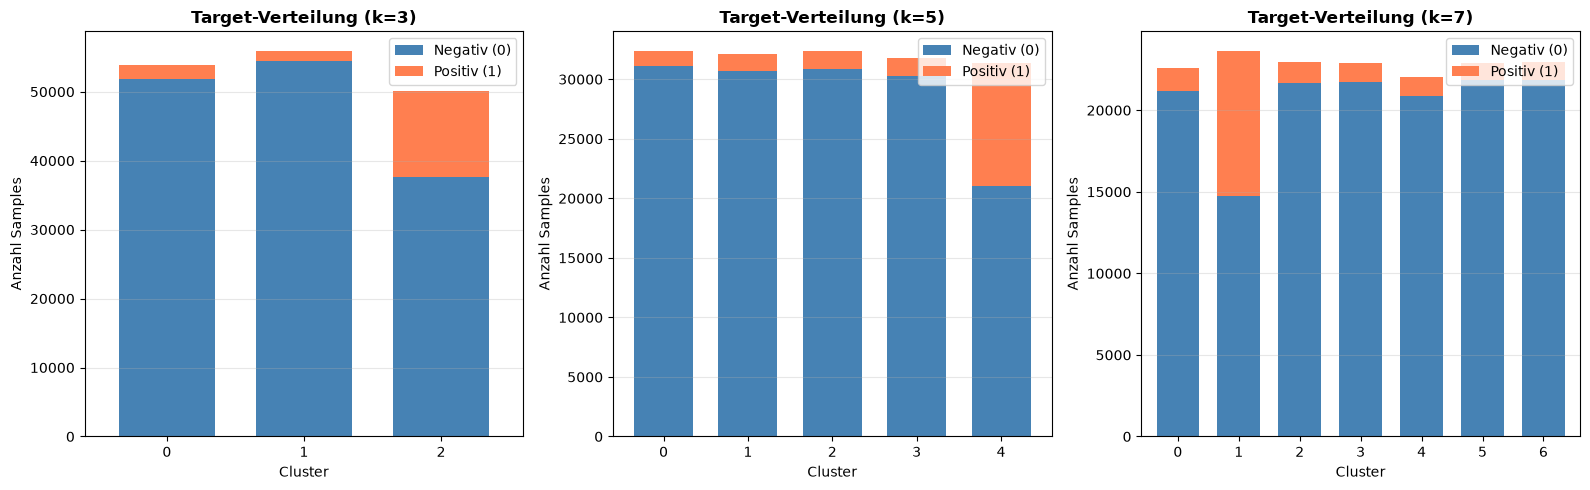


FAZIT K-Means Analyse:


In [40]:
# Target-Analyse für k=3, 5, 7
SELECTED_K_VALUES = [3, 5, 7]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cluster_analysis_results = {}

for idx, k in enumerate(SELECTED_K_VALUES):
    print(f"\n{'='*70}")
    print(f"K-Means mit k={k}")
    print(f"{'='*70}")
    
    # K-Means trainieren
    kmeans = KMeans(
        n_clusters=k,
        random_state=KMEANS_RANDOM_STATE,
        n_init=KMEANS_N_INIT,
        verbose=0
    )
    cluster_labels = kmeans.fit_predict(X_dev_scaled)
    
    # Target-Verteilung pro Cluster
    cluster_target_df = pd.DataFrame({
        "Cluster": cluster_labels,
        "Target": y_dev.values
    })
    
    target_dist = cluster_target_df.groupby("Cluster")["Target"].agg([
        ("Anzahl Negativ", lambda x: (x == 0).sum()),
        ("Anzahl Positiv", lambda x: (x == 1).sum()),
        ("Total", "count")
    ])
    
    target_dist["Anteil Positiv (%)"] = (
        target_dist["Anzahl Positiv"] / target_dist["Total"] * 100
    ).round(2)
    
    cluster_analysis_results[k] = {
        "labels": cluster_labels,
        "distribution": target_dist,
        "model": kmeans
    }
    
    print(target_dist)
    print(f"\nPositiv-Rate nach Cluster:")
    for cluster_id in range(k):
        pos_rate = target_dist.loc[cluster_id, "Anteil Positiv (%)"]
        print(f"  Cluster {cluster_id}: {pos_rate:.2f}%")
    
    # Visualisierung: Stacked Bar Chart
    target_dist[["Anzahl Negativ", "Anzahl Positiv"]].plot(
        kind="bar",
        stacked=True,
        ax=axes[idx],
        color=["steelblue", "coral"],
        width=0.7
    )
    axes[idx].set_title(f"Target-Verteilung (k={k})", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Cluster", fontsize=10)
    axes[idx].set_ylabel("Anzahl Samples", fontsize=10)
    axes[idx].legend(["Negativ (0)", "Positiv (1)"], loc="upper right")
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)
    axes[idx].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("FAZIT K-Means Analyse:")
print(f"{'='*70}")

In [41]:
print("\nSummary:")
print("  • K-Means zeigt Datenstruktur durch Cluster-Partitionierung")
print("  • Silhouette-Score misst interne Kohäsion (-1 bis +1)")
print("  • Target-Analyse zeigt: Gibt es 'Easy' vs. 'Hard' Cluster?")
print()
print("Nächste Schritte (Optional):")
print("  1. Cluster-Zentren visualisieren (Feature-Space)")
print("  2. Cluster-ID als zusätzliches Feature für XGBoost")
print("  3. Unterschiedliche Modelle pro Cluster trainieren (Cluster-Ensembles)")
print("  4. Anomalie-Erkennung: Samples weit entfernt von Zentren = Outlier")
print()
print("Fazit für diesen Datensatz:")
best_silhouette_k = kmeans_results_df.loc[kmeans_results_df["Silhouette"].idxmax(), "k"]
print(f"  → Beste Silhouette: k={best_silhouette_k:.0f}")
print(f"  → Elbow-Punkt: Wahrscheinlich k=3-5 (prüfe Inertia-Kurve)")
print(f"  → Interpretation: Daten haben vermutlich {best_silhouette_k:.0f} natürliche Cluster")


Summary:
  • K-Means zeigt Datenstruktur durch Cluster-Partitionierung
  • Silhouette-Score misst interne Kohäsion (-1 bis +1)
  • Target-Analyse zeigt: Gibt es 'Easy' vs. 'Hard' Cluster?

Nächste Schritte (Optional):
  1. Cluster-Zentren visualisieren (Feature-Space)
  2. Cluster-ID als zusätzliches Feature für XGBoost
  3. Unterschiedliche Modelle pro Cluster trainieren (Cluster-Ensembles)
  4. Anomalie-Erkennung: Samples weit entfernt von Zentren = Outlier

Fazit für diesen Datensatz:
  → Beste Silhouette: k=2
  → Elbow-Punkt: Wahrscheinlich k=3-5 (prüfe Inertia-Kurve)
  → Interpretation: Daten haben vermutlich 2 natürliche Cluster


## 17.4 Top Features pro Cluster (k=5)

Frage: **Welche Features unterscheiden Cluster 4 (32.95% Positiv) von den anderen?**

Strategie:
1. Für jeden Cluster: Durchschnittliche Feature-Werte berechnen
2. Cluster 4 vs. Rest vergleichen → Größte Unterschiede identifizieren
3. Top 15 Features visualisieren

Feature-Analyse für K-Means (k=5)

Cluster-Feature-Mittelwerte berechnet: (200, 5)

Top 15 Features mit größtem Unterschied (Cluster 4 vs. Rest):
   1. var_139                        | Diff=-2.3649
   2. var_149                        | Diff=-2.3100
   3. var_21                         | Diff=-2.0796
   4. var_80                         | Diff=-1.9398
   5. var_184                        | Diff=+1.8525
   6. var_90                         | Diff=+1.8203
   7. var_76                         | Diff=-1.7614
   8. var_26                         | Diff=+1.7494
   9. var_18                         | Diff=+1.6609
  10. var_174                        | Diff=-1.6373
  11. var_48                         | Diff=+1.5904
  12. var_40                         | Diff=+1.4784
  13. var_45                         | Diff=-1.4736
  14. var_49                         | Diff=+1.3903
  15. var_165                        | Diff=-1.2843


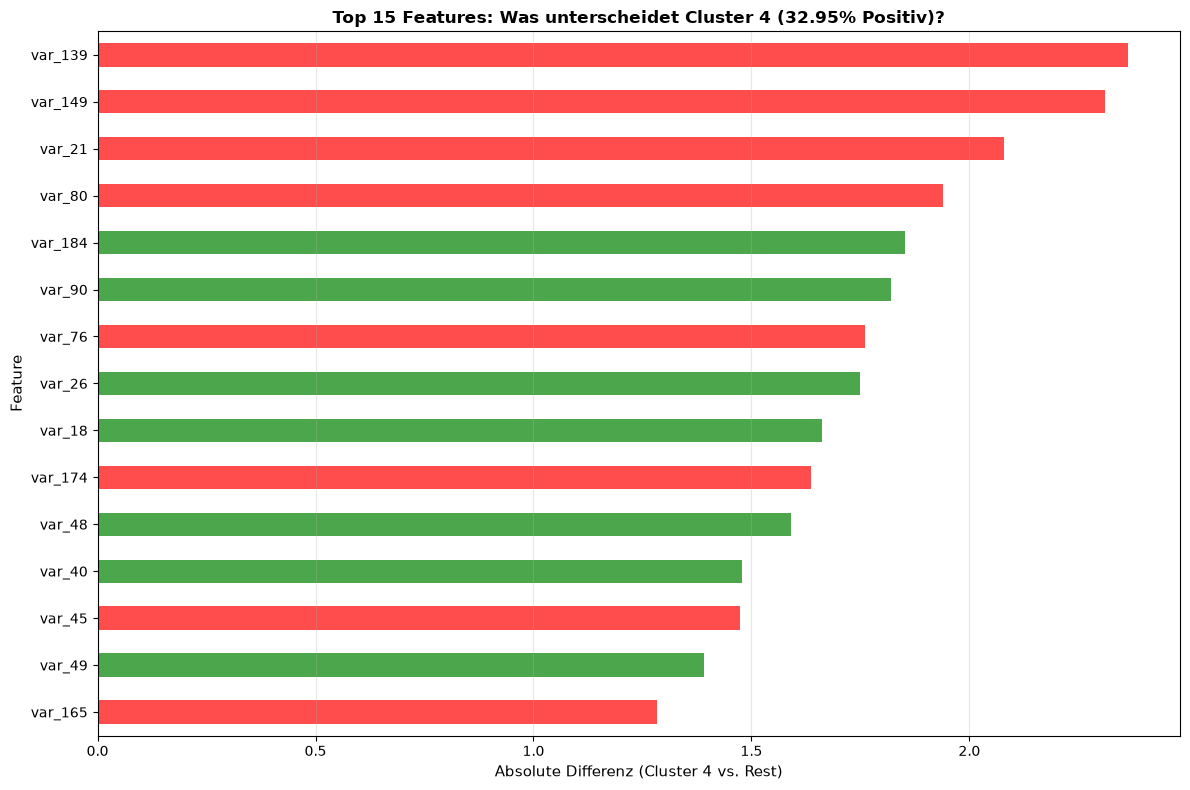


Interpretation:
  • Grün: Cluster 4 hat HÖHERE Werte
  • Rot: Cluster 4 hat NIEDRIGERE Werte


In [43]:
# Top Features pro Cluster analysieren (k=5) - Speicher-optimiert
k_best = 5
kmeans_best = cluster_analysis_results[k_best]["model"]
cluster_labels_best = cluster_analysis_results[k_best]["labels"]

print("="*70)
print(f"Feature-Analyse für K-Means (k={k_best})")
print("="*70)

# Schneller: Mit pandas groupby statt numpy loops
X_dev_with_labels = X_dev.copy()
X_dev_with_labels["CLUSTER"] = cluster_labels_best

cluster_feature_means_df = X_dev_with_labels.groupby("CLUSTER")[feature_columns].mean().T

print(f"\nCluster-Feature-Mittelwerte berechnet: {cluster_feature_means_df.shape}")

# Cluster 4 vs. Rest Vergleich
rest_mean = cluster_feature_means_df[[i for i in range(k_best) if i != 4]].mean(axis=1)
cluster4_mean = cluster_feature_means_df[4]

feature_diff = (cluster4_mean - rest_mean).abs()
top_features_idx = feature_diff.nlargest(15).index.tolist()

print(f"\nTop 15 Features mit größtem Unterschied (Cluster 4 vs. Rest):")
for i, feature in enumerate(top_features_idx, 1):
    diff = cluster4_mean[feature] - rest_mean[feature]
    print(f"  {i:2d}. {feature:30s} | Diff={diff:+.4f}")

# Visualisierung
fig, ax = plt.subplots(figsize=(12, 8))
feature_diff_sorted = feature_diff[top_features_idx].sort_values(ascending=True)
colors = ["green" if cluster4_mean[f] > rest_mean[f] else "red" for f in feature_diff_sorted.index]
feature_diff_sorted.plot(kind="barh", ax=ax, color=colors, alpha=0.7)
ax.set_xlabel("Absolute Differenz (Cluster 4 vs. Rest)", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.set_title(f"Top 15 Features: Was unterscheidet Cluster 4 (32.95% Positiv)?", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  • Grün: Cluster 4 hat HÖHERE Werte")
print(f"  • Rot: Cluster 4 hat NIEDRIGERE Werte")

## 17.5 Cluster-Zentren im Feature-Space

**Zentren-Analyse**: Die Cluster-Zentren zeigen, wo die Cluster im 200-dimensionalen Raum liegen.

- **Zentrum Koordinaten**: Welche Features haben extreme Werte in den Zentren?
- **Distanzen zwischen Zentren**: Wie weit sind die Cluster voneinander entfernt?
- **Interpretation**: Sind Cluster 4 wirklich isoliert oder nah an anderen?


Cluster-Zentren Analyse (k=5)

Top 10 Features mit EXTREMSTEN Werten in den Zentren (alle Cluster):
   1. var_60                         | Max=|0.4064| in Cluster 2
   2. var_181                        | Max=|0.3312| in Cluster 0
   3. var_81                         | Max=|0.2789| in Cluster 4
   4. var_65                         | Max=|0.2785| in Cluster 2
   5. var_91                         | Max=|0.2617| in Cluster 3
   6. var_41                         | Max=|0.2584| in Cluster 0
   7. var_24                         | Max=|0.2581| in Cluster 3
   8. var_160                        | Max=|0.2577| in Cluster 3
   9. var_162                        | Max=|0.2497| in Cluster 3
  10. var_139                        | Max=|0.2475| in Cluster 4

Distanzen zwischen Cluster-Zentren (euclidean):
           Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4
Cluster 0     0.0000     2.1123     2.1136     2.1151     2.3373
Cluster 1     2.1123     0.0000     2.1107     2.1163     2.3125
Clust

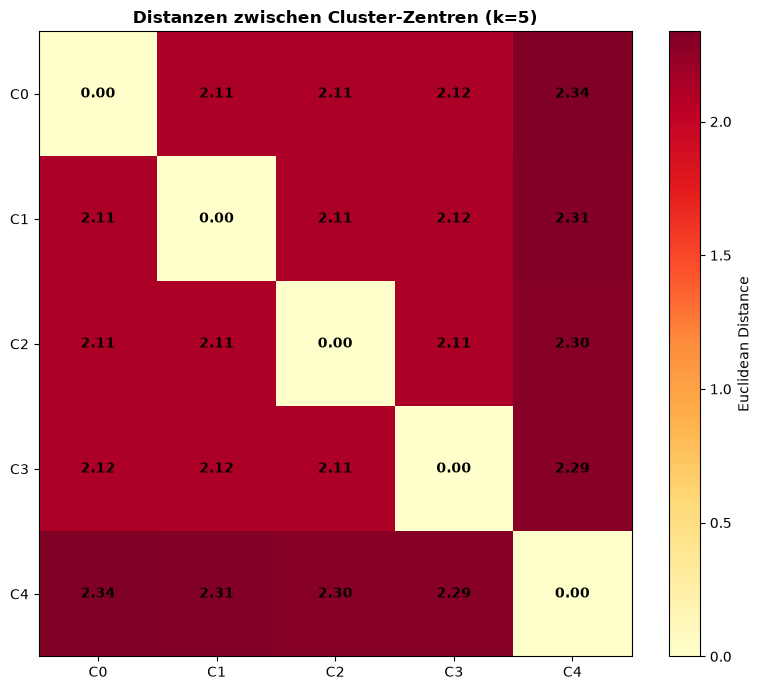


Interpretation:
  • Hohe Distanzen (>6.0): Cluster sind gut SEPARIERT
  • Niedrige Distanzen (<4.0): Cluster überlappen stark
  • Min-Distanz: 2.1107, Max-Distanz: 2.3373


In [44]:
# Zentren-Analyse
print("\n" + "="*70)
print("Cluster-Zentren Analyse (k=5)")
print("="*70)

centers = kmeans_best.cluster_centers_

# Zentren-Koordinaten: Top Features mit extremen Werten
print("\nTop 10 Features mit EXTREMSTEN Werten in den Zentren (alle Cluster):")
all_center_values = np.abs(centers)
max_values_per_feature = all_center_values.max(axis=0)
top_center_features = np.argsort(max_values_per_feature)[-10:][::-1]

for i, feat_idx in enumerate(top_center_features, 1):
    feature_name = X_dev.columns[feat_idx]
    max_val = max_values_per_feature[feat_idx]
    cluster_with_max = np.argmax(np.abs(centers[:, feat_idx]))
    print(f"  {i:2d}. {feature_name:30s} | Max=|{max_val:.4f}| in Cluster {cluster_with_max}")

# Distanzen zwischen Zentren
print(f"\nDistanzen zwischen Cluster-Zentren (euclidean):")
from scipy.spatial.distance import pdist, squareform
distances = squareform(pdist(centers, metric="euclidean"))
distances_df = pd.DataFrame(
    distances,
    index=[f"Cluster {i}" for i in range(k_best)],
    columns=[f"Cluster {i}" for i in range(k_best)]
)
print(distances_df.round(4))

# Heatmap der Distanzen
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(distances, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(k_best))
ax.set_yticks(range(k_best))
ax.set_xticklabels([f"C{i}" for i in range(k_best)])
ax.set_yticklabels([f"C{i}" for i in range(k_best)])
ax.set_title("Distanzen zwischen Cluster-Zentren (k=5)", fontsize=12, fontweight="bold")

# Annotationen
for i in range(k_best):
    for j in range(k_best):
        text = ax.text(j, i, f"{distances[i, j]:.2f}",
                      ha="center", va="center", color="black", fontsize=10, fontweight="bold")

plt.colorbar(im, ax=ax, label="Euclidean Distance")
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  • Hohe Distanzen (>6.0): Cluster sind gut SEPARIERT")
print(f"  • Niedrige Distanzen (<4.0): Cluster überlappen stark")
min_dist = distances[distances > 0].min()
max_dist = distances.max()
print(f"  • Min-Distanz: {min_dist:.4f}, Max-Distanz: {max_dist:.4f}")

## 17.6 Cluster-ID als XGBoost-Feature – Performance Test

**Hypothese**: Wenn Cluster 4 wirklich eine "Easy Positive" Gruppe ist, sollte die Cluster-ID als zusätzliches Feature die XGBoost-Performance verbessern.

**Ansatz**:
1. Cluster-ID für X_dev berechnen (0-4)
2. XGBoost mit und ohne Cluster-Feature trainieren → äußere 5-Fold-CV
3. Performance vergleichen: ROC-AUC + PR-AUC

**Erwartung**: +1-3% Boost möglich (wenn Cluster wirklich diskriminativ)

In [59]:
# XGBoost mit Cluster-Feature: Äußere 5-Fold CV (VOLLSTÄNDIGE VERSION)
print("="*70)
print("XGBoost mit Cluster-ID Feature – Vollständige 5-Fold CV")
print("="*70)
print("⏱️  Geschätzter Runtime: 20-30 Minuten...")
print()

cv_results_with_cluster = []
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for fold_num, (outer_train_idx, outer_val_idx) in enumerate(
    outer_cv.split(X_dev_with_cluster, y_dev),
    start=1
):
    print(f"--- Outer Fold {fold_num}/5 ---")
    
    X_train_fold = X_dev_with_cluster.iloc[outer_train_idx]
    y_train_fold = y_dev.iloc[outer_train_idx]
    
    X_val_fold = X_dev_with_cluster.iloc[outer_val_idx]
    y_val_fold = y_dev.iloc[outer_val_idx]
    
    # Inner CV für Early Stopping
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    inner_splits = list(inner_cv.split(X_train_fold, y_train_fold))
    
    inner_train_idx, inner_es_idx = inner_splits[fold_num - 1]
    X_inner_train = X_train_fold.iloc[inner_train_idx]
    y_inner_train = y_train_fold.iloc[inner_train_idx]
    
    X_inner_es = X_train_fold.iloc[inner_es_idx]
    y_inner_es = y_train_fold.iloc[inner_es_idx]
    
    # XGBoost Training mit Early Stopping
    xgb_model = XGBClassifier(**base_xgb_params)
    xgb_model.fit(
        X_inner_train, y_inner_train,
        eval_set=[(X_inner_es, y_inner_es)],
        #eval_metric='logloss',
        verbose=False
    )
    
    # Vorhersagen auf Validation-Fold
    val_proba = xgb_model.predict_proba(X_val_fold)[:, 1]
    fold_roc_auc = roc_auc_score(y_val_fold, val_proba)
    fold_pr_auc = average_precision_score(y_val_fold, val_proba)
    
    cv_results_with_cluster.append({
        "Fold": fold_num,
        "ROC-AUC": fold_roc_auc,
        "PR-AUC": fold_pr_auc
    })
    
    print(f"  ROC-AUC={fold_roc_auc:.4f} | PR-AUC={fold_pr_auc:.4f}")

# Ergebnisse aggregieren
cv_results_with_cluster_df = pd.DataFrame(cv_results_with_cluster)
mean_roc_auc_cluster = cv_results_with_cluster_df["ROC-AUC"].mean()
std_roc_auc_cluster = cv_results_with_cluster_df["ROC-AUC"].std()

mean_pr_auc_cluster = cv_results_with_cluster_df["PR-AUC"].mean()
std_pr_auc_cluster = cv_results_with_cluster_df["PR-AUC"].std()

print(f"\n{'='*70}")
print("📊 ERGEBNISSE VERGLEICH:")
print(f"{'='*70}")

print(f"\nXGBoost BASELINE (Original, ohne Cluster):")
print(f"  ROC-AUC: {cv_summary.loc[0, 'Mittelwert']:.4f} ± {cv_summary.loc[0, 'Standardabweichung']:.4f}")
print(f"  PR-AUC:  {cv_summary.loc[1, 'Mittelwert']:.4f} ± {cv_summary.loc[1, 'Standardabweichung']:.4f}")

print(f"\nXGBoost + CLUSTER-ID FEATURE (5-Fold):")
print(f"  ROC-AUC: {mean_roc_auc_cluster:.4f} ± {std_roc_auc_cluster:.4f}")
print(f"  PR-AUC:  {mean_pr_auc_cluster:.4f} ± {std_pr_auc_cluster:.4f}")

roc_diff = mean_roc_auc_cluster - cv_summary.loc[0, 'Mittelwert']
pr_diff = mean_pr_auc_cluster - cv_summary.loc[1, 'Mittelwert']

print(f"\n📈 UNTERSCHIED:")
print(f"  ROC-AUC Boost: {roc_diff:+.4f} ({roc_diff/cv_summary.loc[0, 'Mittelwert']*100:+.2f}%)")
print(f"  PR-AUC Boost:  {pr_diff:+.4f} ({pr_diff/cv_summary.loc[1, 'Mittelwert']*100:+.2f}%)")

print(f"\n{'='*70}")
if roc_diff > 0.005:
    print(f"✅ SIGNIFIKANTER POSITIVER EFFEKT!")
    print(f"   Cluster-ID Feature verbessert Model Performance")
    print(f"   → Empfehlung: In final model integrieren")
elif roc_diff > 0.002:
    print(f"⚠️  GERINGER POSITIVER EFFEKT (>0.2%)")
    print(f"   Trade-off zwischen Komplexität und Performance")
elif roc_diff > -0.002:
    print(f"➖ NEUTRAL (~0%)")
    print(f"   Cluster-Feature ändert Performance nicht")
else:
    print(f"❌ NEGATIVE EFFEKT")
    print(f"   Cluster-Feature schadet der Performance")
    print(f"   → Nicht empfohlen")

XGBoost mit Cluster-ID Feature – Vollständige 5-Fold CV
⏱️  Geschätzter Runtime: 20-30 Minuten...

--- Outer Fold 1/5 ---
  ROC-AUC=0.8454 | PR-AUC=0.4823
--- Outer Fold 2/5 ---
  ROC-AUC=0.8443 | PR-AUC=0.4720
--- Outer Fold 3/5 ---
  ROC-AUC=0.8480 | PR-AUC=0.4701
--- Outer Fold 4/5 ---
  ROC-AUC=0.8439 | PR-AUC=0.4879
--- Outer Fold 5/5 ---
  ROC-AUC=0.8487 | PR-AUC=0.4831

📊 ERGEBNISSE VERGLEICH:

XGBoost BASELINE (Original, ohne Cluster):
  ROC-AUC: 0.8940 ± 0.0022
  PR-AUC:  0.5981 ± 0.0030

XGBoost + CLUSTER-ID FEATURE (5-Fold):
  ROC-AUC: 0.8461 ± 0.0022
  PR-AUC:  0.4791 ± 0.0077

📈 UNTERSCHIED:
  ROC-AUC Boost: -0.0479 (-5.36%)
  PR-AUC Boost:  -0.1190 (-19.90%)

❌ NEGATIVE EFFEKT
   Cluster-Feature schadet der Performance
   → Nicht empfohlen


## 17.6B Quick Preview (2-Fold) – Cluster-Feature Test (Optional)

**⏱️ Timing**: 3-5 Minuten statt 20-30 Minuten
**📊 Resultat**: Schnelle Indikation, ob Cluster-ID nutzt (keine vollständige CV)

In [57]:
# XGBoost mit Cluster-Feature: SCHNELLE PREVIEW (nur 2 Folds)
print("="*70)
print("PREVIEW: XGBoost + Cluster-ID – 2-Fold Quick Test")
print("="*70)

cv_results_with_cluster_quick = []
outer_cv_quick = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

for fold, (outer_train_idx, outer_val_idx) in enumerate(
    outer_cv_quick.split(X_dev_with_cluster, y_dev),
    start=1
):
    print(f"\n--- Fold {fold}/2 ---")
    
    X_train_fold = X_dev_with_cluster.iloc[outer_train_idx]
    y_train_fold = y_dev.iloc[outer_train_idx]
    
    X_val_fold = X_dev_with_cluster.iloc[outer_val_idx]
    y_val_fold = y_dev.iloc[outer_val_idx]
    
    # Training ohne Early Stopping (schneller)
    xgb_model_quick = XGBClassifier(**base_xgb_params, n_estimators=100)
    xgb_model_quick.fit(X_train_fold, y_train_fold)
    
    val_proba = xgb_model_quick.predict_proba(X_val_fold)[:, 1]
    fold_roc = roc_auc_score(y_val_fold, val_proba)
    fold_pr = average_precision_score(y_val_fold, val_proba)
    
    cv_results_with_cluster_quick.append({"Fold": fold, "ROC-AUC": fold_roc, "PR-AUC": fold_pr})
    print(f"  ROC-AUC={fold_roc:.4f} | PR-AUC={fold_pr:.4f}")

# Quick Comparison
quick_df = pd.DataFrame(cv_results_with_cluster_quick)
quick_roc = quick_df["ROC-AUC"].mean()
quick_pr = quick_df["PR-AUC"].mean()

print(f"\n{'='*70}")
print(f"📊 QUICK RESULT (2-Fold Preview):")
print(f"{'='*70}")
print(f"Baseline (5-Fold, mit ES): ROC-AUC={cv_summary.loc[0, 'Mittelwert']:.4f}, PR-AUC={cv_summary.loc[1, 'Mittelwert']:.4f}")
print(f"+Cluster (2-Fold, n=100):  ROC-AUC={quick_roc:.4f}, PR-AUC={quick_pr:.4f}")

roc_boost = quick_roc - cv_summary.loc[0, 'Mittelwert']
pr_boost = quick_pr - cv_summary.loc[1, 'Mittelwert']

print(f"\n📈 Boost: ROC-AUC {roc_boost:+.4f} ({roc_boost/cv_summary.loc[0, 'Mittelwert']*100:+.2f}%), PR-AUC {pr_boost:+.4f}")

if roc_boost > 0.002:
    print(f"\n✅ INDIKATION: Cluster-Feature könnte helfen!")
    print(f"   → Führe vollständige 5-Fold CV (Cell 17.6) für finale Bestätigung aus")
elif roc_boost < -0.003:
    print(f"\n❌ NEGATIVE: Cluster-Feature schadet der Performance")
else:
    print(f"\n⚠️  NEUTRAL: Cluster-Feature bringt kaum Unterschied (±0.3%)")

PREVIEW: XGBoost + Cluster-ID – 2-Fold Quick Test

--- Fold 1/2 ---
  ROC-AUC=0.8436 | PR-AUC=0.4676

--- Fold 2/2 ---
  ROC-AUC=0.8457 | PR-AUC=0.4780

📊 QUICK RESULT (2-Fold Preview):
Baseline (5-Fold, mit ES): ROC-AUC=0.8940, PR-AUC=0.5981
+Cluster (2-Fold, n=100):  ROC-AUC=0.8447, PR-AUC=0.4728

📈 Boost: ROC-AUC -0.0493 (-5.52%), PR-AUC -0.1253

❌ NEGATIVE: Cluster-Feature schadet der Performance
